# 13 — Encoding Manifold-Based Subpopulation Analysis

**Core claim:** Decoding equivalence ≠ representational equivalence.

Three experiments, each building toward the adversarial demonstration:

1. **Random sampling** — baseline: visualise selected neurons on encoding manifold, compute all decoding scores
2. **Manifold-region biased sampling** — select neurons from a spatial region of the MDS embedding, compare to random
3. **Synthetic clustered manifold** — construct a new population that replicates decoding metrics while reshaping encoding manifold topology from smooth → clustered

Requires: `load_for_explorer('V1')` to have been run (notebook 03 must have generated `data/graphs/V1_*.npz`).

In [17]:
import sys, os, warnings, time, math
sys.path.insert(0, '..')
warnings.filterwarnings('ignore')

import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa

from src.cache_utils import load_for_explorer
from src.subpop_utils import (
    select_neurons_by_bbox,
    select_neurons_by_radius,
    compute_decoding_manifold,
    compute_decoding_trajectories,
    knn_decoding_accuracy,
    rdm_correlation,
    linear_cka,
    procrustes_r2,
    variance_reproduced,
    plot_neuron_locations_in_manifold,
    plot_encoding_manifold_3d,
    create_synthetic_clustered_population,
    create_clustered_by_amplification,
    create_clustered_by_centroid,
    compute_encoding_manifold_from_tensor,
)

BASEDIR_FIG = '../fig/subpop_critique'
os.makedirs(BASEDIR_FIG, exist_ok=True)

# Colour palette for decoding manifold — matches notebook 04 exactly
_PALETTE = ['#0070C0', '#00B0F0', '#00B050', '#92D050', '#FF0000', '#FFC000',
             '#7030A0', '#FF6600', '#339933', '#CC0066', '#009999', '#996633']


## 0 — Load data

In [18]:
PREFIX = 'V1'

t0 = time.time()
data = load_for_explorer(PREFIX)
print(f'Loaded {PREFIX} in {time.time()-t0:.1f}s')

# Full-population encoding manifold (CP-based pipeline)
embedding_full = data['embedding_']        # (N_nonout, 10)  MDS coords

# Raw tensor for decoding — shape from explorer is (N, S, T, D); transpose to (N, S, D, T)
tensor4d_NSDT = data['tensor4d_raw'].transpose(0, 1, 3, 2)   # (N_nonout, S, D, T)

NSTIMS   = data['NSTIMS']
NDIRS    = data['NDIRS']
N_nonout = len(embedding_full)

# Stimulus colours matched to nb04 palette
STIM_COLORS = (_PALETTE * math.ceil(NSTIMS / len(_PALETTE)))[:NSTIMS]

# Stimulus labels for LOO k-NN: each of the S*D points labelled by stimulus index
stim_labels = np.repeat(np.arange(NSTIMS), NDIRS)    # (S*D,)

print(f'N_nonout={N_nonout}, NSTIMS={NSTIMS}, NDIRS={NDIRS}')
print(f'tensor4d shape (N,S,D,T): {tensor4d_NSDT.shape}')
print(f'embedding shape: {embedding_full.shape}')
print(f'STIM_COLORS ({len(STIM_COLORS)}): {STIM_COLORS}')


../data/decompositions/V1-relNorm_sig3_n637-deepnet-shift*_F*.mat
F17: (30)
Loaded V1 in 4.1s
N_nonout=630, NSTIMS=6, NDIRS=8
tensor4d shape (N,S,D,T): (630, 6, 8, 135)
embedding shape: (630, 10)
STIM_COLORS (6): ['#0070C0', '#00B0F0', '#00B050', '#92D050', '#FF0000', '#FFC000']
Loaded V1 in 4.1s
N_nonout=630, NSTIMS=6, NDIRS=8
tensor4d shape (N,S,D,T): (630, 6, 8, 135)
embedding shape: (630, 10)
STIM_COLORS (6): ['#0070C0', '#00B0F0', '#00B050', '#92D050', '#FF0000', '#FFC000']


In [19]:
# Full-population decoding (reference for all comparisons)
coords_full, _ = compute_decoding_manifold(tensor4d_NSDT)
acc_full = knn_decoding_accuracy(coords_full, stim_labels)
print(f'Full population kNN accuracy: {acc_full:.3f}')

Full population kNN accuracy: 0.875


In [20]:
# Helper: evaluate and visualise a subpopulation
def evaluate_subpop(idx, label='subpop', show_plot=True):
    """Compute all 5 decoding metrics for a subpopulation and visualise it.

    Three-panel figure:
      1. Encoding manifold — full pop in gray, selected in orange
      2. Decoding manifold — stimulus-coloured scatter (nb04 palette)
      3. Decoding trajectories — time-resolved PCA paths
    """
    idx = np.asarray(idx)
    mask = np.zeros(N_nonout, dtype=bool)
    mask[idx] = True

    tensor_sub = tensor4d_NSDT[idx]             # (k, S, D, T)
    coords_sub, _ = compute_decoding_manifold(tensor_sub)
    trajs_sub, _  = compute_decoding_trajectories(tensor_sub)

    acc = knn_decoding_accuracy(coords_sub, stim_labels)
    rdm = rdm_correlation(tensor4d_NSDT, tensor_sub)
    cka = linear_cka(tensor4d_NSDT, tensor_sub)
    r2  = procrustes_r2(coords_full, coords_sub)
    var = variance_reproduced(coords_full, coords_sub)

    r2_str  = f'{r2:.3f}'  if (r2  is not None and not np.isnan(r2))  else ' nan'
    var_str = f'{var:.3f}' if (var is not None and not np.isnan(var)) else ' nan'
    print(f'[{label}]  N={len(idx)} ({100*len(idx)/N_nonout:.0f}%)'
          f'  kNN={acc:.3f} ({100*acc/acc_full:.0f}% of full)'
          f'  RDM \u03c1={rdm:.3f}  CKA={cka:.3f}  R\u00b2={r2_str}  var={var_str}')

    if show_plot:
        fig = plt.figure(figsize=(18, 5))

        # Panel 1 — encoding manifold
        ax1 = fig.add_subplot(1, 3, 1, projection='3d')
        Y = embedding_full
        ax1.scatter(*Y[~mask].T[:3], c='lightgray', s=8, alpha=0.4,
                    edgecolors='none', depthshade=False)
        ax1.scatter(*Y[mask].T[:3], c='darkorange', s=30, alpha=0.9,
                    edgecolors='none', depthshade=False)
        ax1.set_xticks([]); ax1.set_yticks([]); ax1.set_zticks([])
        ax1.set_title(f'Encoding manifold\n(orange = selected, N={len(idx)})', fontsize=9)
        ax1.view_init(elev=30, azim=45)

        # Panel 2 — decoding manifold
        ax2 = fig.add_subplot(1, 3, 2, projection='3d')
        for si in range(NSTIMS):
            sel = stim_labels == si
            lbl = data['my_stims'][si] if si < len(data['my_stims']) else f's{si}'
            ax2.scatter(coords_sub[sel, 0], coords_sub[sel, 1], coords_sub[sel, 2],
                        c=STIM_COLORS[si % len(STIM_COLORS)], s=120, alpha=1.0,
                        edgecolors='none', depthshade=False, label=lbl)
        ax2.set_xticks([]); ax2.set_yticks([]); ax2.set_zticks([])
        ax2.set_title(f'Decoding manifold\nkNN={acc:.3f}  RDM \u03c1={rdm:.3f}', fontsize=9)
        ax2.view_init(elev=30, azim=45)
        ax2.legend(fontsize=7, loc='upper left', framealpha=0.6)

        # Panel 3 — decoding trajectories
        ax3 = fig.add_subplot(1, 3, 3, projection='3d')
        for i, traj in enumerate(trajs_sub):
            si = i // NDIRS
            col = STIM_COLORS[si % len(STIM_COLORS)]
            valid = ~np.any(np.isnan(traj), axis=1)
            tv = traj[valid]
            if len(tv) < 2:
                continue
            ax3.plot(tv[:, 0], tv[:, 1], tv[:, 2],
                     color=col, linewidth=2, alpha=0.3)
            ax3.scatter(tv[0, 0], tv[0, 1], tv[0, 2],
                        color='black', s=25, edgecolors='none', depthshade=False)
            ax3.scatter(tv[-1, 0], tv[-1, 1], tv[-1, 2],
                        color=col, s=100, edgecolors='none', depthshade=False)
        ax3.set_xticks([]); ax3.set_yticks([]); ax3.set_zticks([])
        ax3.set_title(f'Decoding trajectories\nCKA={cka:.3f}  R\u00b2={r2_str}', fontsize=9)
        ax3.view_init(elev=30, azim=45)

        fig.suptitle(label, fontsize=11, y=1.01)
        plt.tight_layout()
        plt.savefig(f'{BASEDIR_FIG}/{PREFIX}_{label.replace(" ", "_")}.pdf',
                    bbox_inches='tight')
        plt.show()

    return dict(acc=acc, rdm=rdm, cka=cka, r2=r2, var=var, mask=mask, n=len(idx))


In [21]:
# Helper: grouped bar chart comparing decoding metrics across conditions
def plot_metrics_bar(conditions, title='Decoding metrics comparison', save_suffix=None):
    """Grouped bar chart of all 5 decoding metrics.

    Parameters
    ----------
    conditions : list of (label, results_list, color)
        results_list is a list of metric dicts; mean ± std taken if multiple.
    title : str
    save_suffix : str or None  — saved to BASEDIR_FIG if provided
    """
    metric_keys   = ['acc',     'rdm',    'cka',  'r2',            'var']
    metric_labels = ['kNN acc', 'RDM \u03c1', 'CKA', 'Procrustes R\u00b2', 'Var. repr.']
    full_refs     = dict(acc=acc_full, rdm=1.0, cka=1.0, r2=1.0, var=1.0)

    n_cond  = len(conditions)
    x       = np.arange(len(metric_keys))
    width   = 0.18
    offsets = np.linspace(-(n_cond - 1) / 2, (n_cond - 1) / 2, n_cond) * width

    fig, ax = plt.subplots(figsize=(10, 4))
    for (lbl, res_list, color), offset in zip(conditions, offsets):
        means, errs = [], []
        for k in metric_keys:
            vals = [r[k] for r in res_list
                    if r.get(k) is not None and not np.isnan(r.get(k, np.nan))]
            means.append(np.nanmean(vals) if vals else np.nan)
            errs.append(np.nanstd(vals)   if len(vals) > 1 else 0.0)
        ax.bar(x + offset, means, width=width, color=color, alpha=0.82,
               yerr=errs, capsize=3, label=lbl)

    # Per-metric reference line (dashed, full population)
    for xi, k in enumerate(metric_keys):
        ax.plot([xi + offsets[0] - width / 2, xi + offsets[-1] + width / 2],
                [full_refs[k], full_refs[k]],
                color='black', linewidth=1.5, linestyle='--')

    ax.set_xticks(x)
    ax.set_xticklabels(metric_labels, fontsize=9)
    ax.set_ylabel('Metric value', fontsize=9)
    ax.set_ylim(bottom=0)
    ax.set_title(f'{PREFIX} \u2014 {title}\n(dashed = full-population reference)',
                 fontsize=10)
    ax.legend(fontsize=8, framealpha=0.8, loc='lower right')
    ax.tick_params(labelsize=8)
    plt.tight_layout()
    if save_suffix:
        plt.savefig(f'{BASEDIR_FIG}/{PREFIX}_{save_suffix}.pdf', bbox_inches='tight')
    plt.show()
    return fig, ax


## 1 — Random Sampling

Baseline: randomly sample `N_SAMPLE` neurons, compute all decoding scores vs. full population, and show which neurons are selected on the encoding manifold.

[random N=100 seed=0]  N=100 (16%)  kNN=0.646 (74% of full)  RDM ρ=0.906  CKA=0.890  R²=0.835  var=0.197


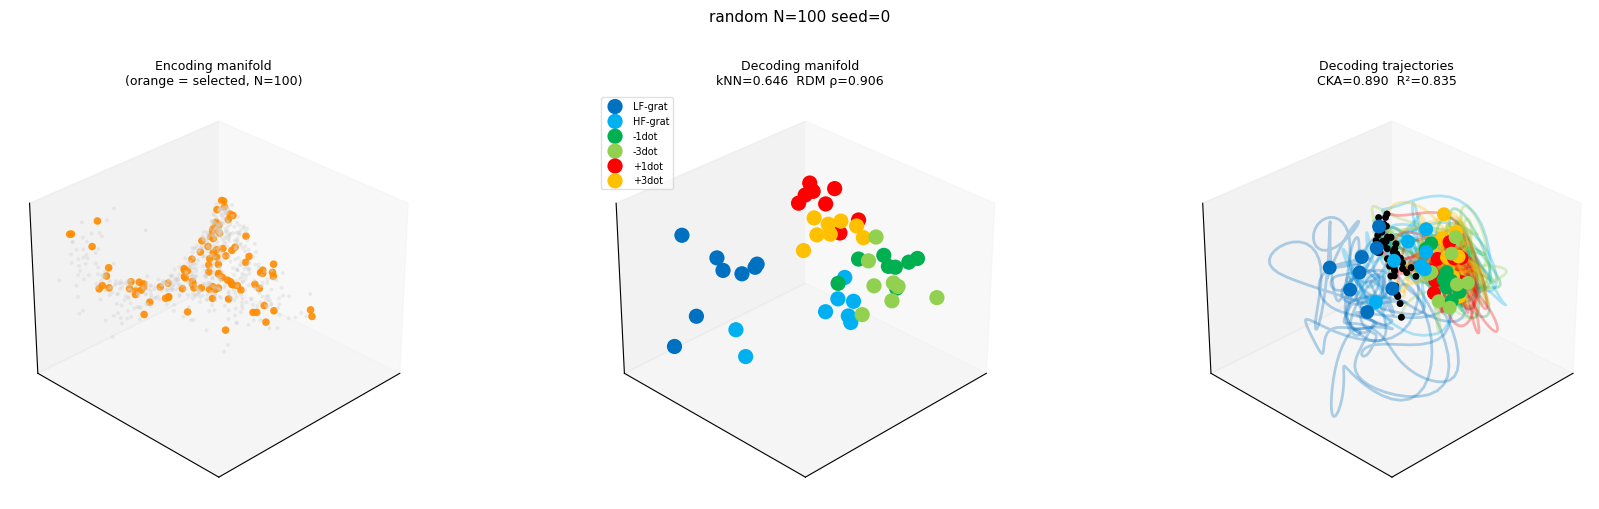

[random N=100 seed=1]  N=100 (16%)  kNN=0.771 (88% of full)  RDM ρ=0.920  CKA=0.936  R²=0.862  var=0.205
[random N=100 seed=2]  N=100 (16%)  kNN=0.875 (100% of full)  RDM ρ=0.931  CKA=0.924  R²=0.919  var=0.137
[random N=100 seed=3]  N=100 (16%)  kNN=0.688 (79% of full)  RDM ρ=0.854  CKA=0.783  R²=0.825  var=0.197
[random N=100 seed=4]  N=100 (16%)  kNN=0.812 (93% of full)  RDM ρ=0.886  CKA=0.878  R²=0.838  var=0.135
  acc : 0.758 ± 0.083
  rdm : 0.900 ± 0.027
  cka : 0.882 ± 0.054
  r2  : 0.856 ± 0.034
  var : 0.174 ± 0.031


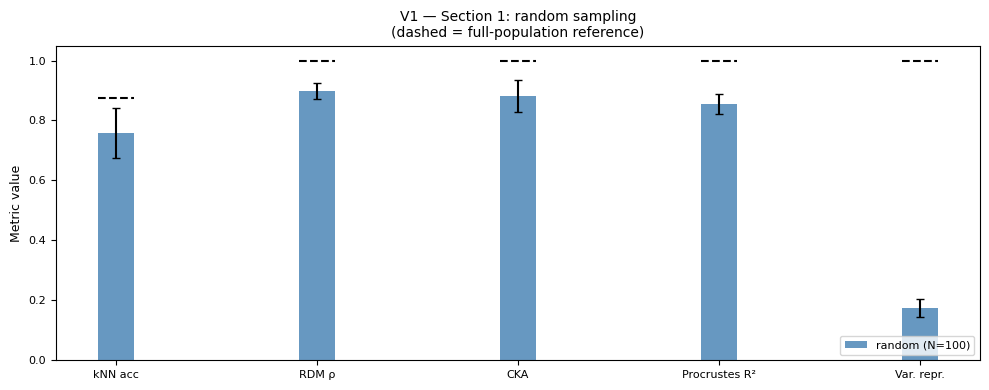

(<Figure size 1000x400 with 1 Axes>,
 <Axes: title={'center': 'V1 — Section 1: random sampling\n(dashed = full-population reference)'}, ylabel='Metric value'>)

In [22]:
# ─── PARAMETERS ──────────────────────────────────────────────────────────────
N_SAMPLE = 100    # number of neurons to sample  ← change this to explore
N_TRIALS = 5      # random draws for mean ± std
# ─────────────────────────────────────────────────────────────────────────────

results_random = []
for seed in range(N_TRIALS):
    rng = np.random.default_rng(seed)
    idx = rng.choice(N_nonout, size=N_SAMPLE, replace=False)
    r = evaluate_subpop(idx, label=f'random N={N_SAMPLE} seed={seed}',
                        show_plot=(seed == 0))   # only plot first trial
    results_random.append(r)

# Summary across trials
for key in ['acc', 'rdm', 'cka', 'r2', 'var']:
    vals = [r[key] for r in results_random]
    print(f'  {key:4s}: {np.nanmean(vals):.3f} ± {np.nanstd(vals):.3f}')

# Metric comparison after Section 1
plot_metrics_bar(
    conditions=[
        (f'random (N={N_SAMPLE})', results_random, 'steelblue'),
    ],
    title='Section 1: random sampling',
    save_suffix='metrics_s1_random',
)


### 1b — Fraction sweep (random baseline)

Vary `N_SAMPLE` to see how decoding degrades as fewer neurons are used.

  f=0.02  k=13  acc=0.608
  f=0.05  k=32  acc=0.637
  f=0.10  k=63  acc=0.625
  f=0.10  k=63  acc=0.625
  f=0.20  k=126  acc=0.721
  f=0.30  k=189  acc=0.767
  f=0.20  k=126  acc=0.721
  f=0.30  k=189  acc=0.767
  f=0.50  k=315  acc=0.850
  f=0.50  k=315  acc=0.850
  f=0.70  k=441  acc=0.871
  f=0.70  k=441  acc=0.871
  f=1.00  k=630  acc=0.875
  f=1.00  k=630  acc=0.875


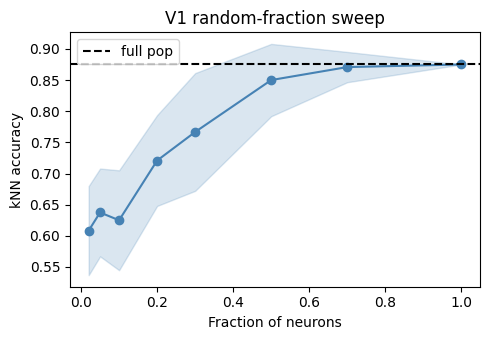

In [23]:
FRACS = [0.02, 0.05, 0.10, 0.20, 0.30, 0.50, 0.70, 1.00]
N_SEEDS_SWEEP = 5

sweep_results = {f: [] for f in FRACS}
for f in FRACS:
    k = max(1, int(round(f * N_nonout)))
    for seed in range(N_SEEDS_SWEEP):
        rng = np.random.default_rng(seed)
        idx = rng.choice(N_nonout, size=k, replace=False)
        tensor_sub = tensor4d_NSDT[idx]
        coords_sub, _ = compute_decoding_manifold(tensor_sub)
        acc = knn_decoding_accuracy(coords_sub, stim_labels)
        sweep_results[f].append(acc)
    mean_acc = np.nanmean(sweep_results[f])
    print(f'  f={f:.2f}  k={k}  acc={mean_acc:.3f}')

fig, ax = plt.subplots(figsize=(5, 3.5))
means = [np.nanmean(sweep_results[f]) for f in FRACS]
stds  = [np.nanstd(sweep_results[f])  for f in FRACS]
ax.plot(FRACS, means, 'o-', color='steelblue')
ax.fill_between(FRACS,
                np.array(means) - np.array(stds),
                np.array(means) + np.array(stds),
                alpha=0.2, color='steelblue')
ax.axhline(acc_full, color='k', linestyle='--', label='full pop')
ax.set_xlabel('Fraction of neurons')
ax.set_ylabel('kNN accuracy')
ax.set_title(f'{PREFIX} random-fraction sweep')
ax.legend()
plt.tight_layout()
plt.savefig(f'{BASEDIR_FIG}/{PREFIX}_random_sweep.pdf', bbox_inches='tight')
plt.show()

## 2 — Manifold-Region Biased Sampling

Select neurons from a specific **spatial region** of the encoding manifold (rather than uniformly at random).  Two options:
- **Percentile**: top fraction along a chosen MDS dimension
- **Radius**: all neurons within a Euclidean radius of a seed point

Visualises the same 2-panel layout so selection patterns are directly comparable.

region-percentile DC0 top25%: 158 neurons (25% of N_nonout)
[region-percentile DC0 top25%]  N=158 (25%)  kNN=0.688 (79% of full)  RDM ρ=0.903  CKA=0.896  R²=0.618  var=0.312
[region-percentile DC0 top25%]  N=158 (25%)  kNN=0.688 (79% of full)  RDM ρ=0.903  CKA=0.896  R²=0.618  var=0.312


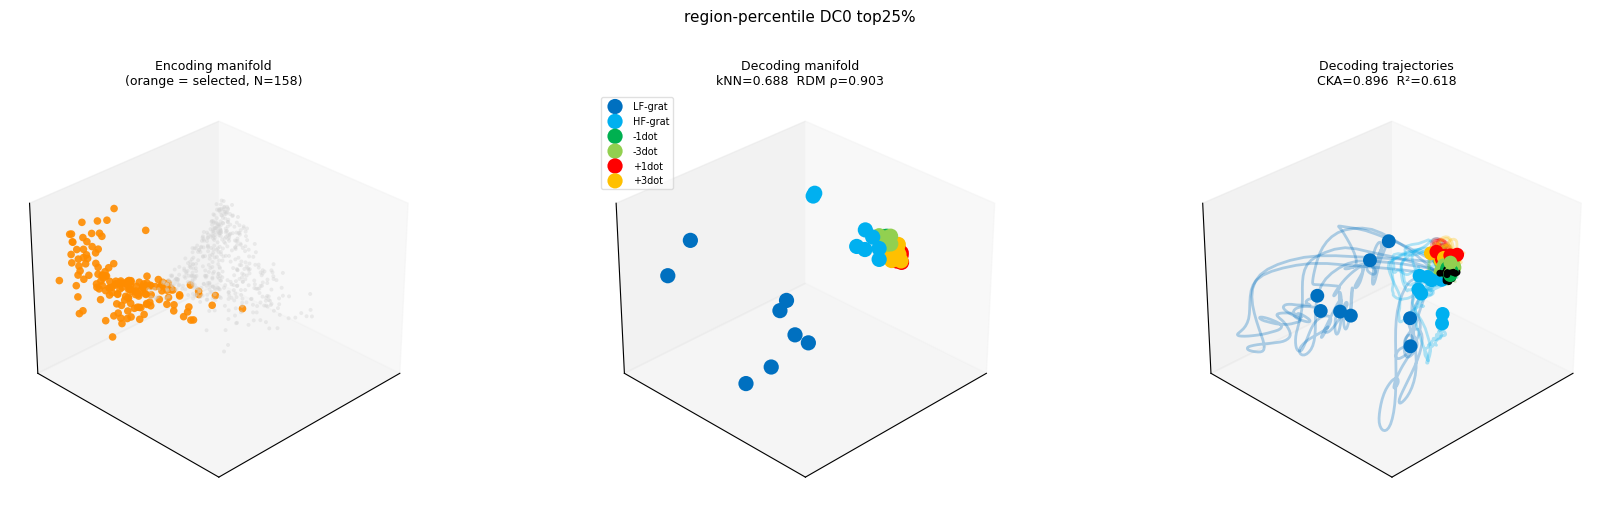

In [24]:
# ─── PARAMETERS ──────────────────────────────────────────────────────────────
REGION_MODE   = 'percentile'   # 'percentile' | 'radius'

# Mode: percentile — select top REGION_FRAC of neurons along DC_IDX
DC_IDX        = 0              # which MDS dimension to use
REGION_FRAC   = 0.25           # top 25% along that dimension

# Mode: radius — select neurons within RADIUS of a seed (most extreme along DC_IDX)
SEED_IDX      = None           # None = auto-pick: most extreme neuron on DC_IDX
RADIUS        = 0.5
# ─────────────────────────────────────────────────────────────────────────────

if REGION_MODE == 'percentile':
    thresh = np.percentile(embedding_full[:, DC_IDX], (1 - REGION_FRAC) * 100)
    mask_region = embedding_full[:, DC_IDX] > thresh
    region_label = f'region-percentile DC{DC_IDX} top{int(REGION_FRAC*100)}%'
else:  # radius
    if SEED_IDX is None:
        SEED_IDX = int(np.argmax(embedding_full[:, DC_IDX]))
    mask_region = select_neurons_by_radius(embedding_full, SEED_IDX, RADIUS)
    region_label = f'region-radius DC{DC_IDX} r={RADIUS} seed={SEED_IDX}'

idx_region = np.where(mask_region)[0]
print(f'{region_label}: {len(idx_region)} neurons ({100*len(idx_region)/N_nonout:.0f}% of N_nonout)')
r_region = evaluate_subpop(idx_region, label=region_label)

[random N=158 seed=0]  N=158 (25%)  kNN=0.646 (74% of full)  RDM ρ=0.920  CKA=0.937  R²=0.756  var=0.296
[random N=158 seed=1]  N=158 (25%)  kNN=0.792 (90% of full)  RDM ρ=0.938  CKA=0.963  R²=0.858  var=0.210
[random N=158 seed=2]  N=158 (25%)  kNN=0.688 (79% of full)  RDM ρ=0.929  CKA=0.946  R²=0.915  var=0.218
[random N=158 seed=3]  N=158 (25%)  kNN=0.750 (86% of full)  RDM ρ=0.938  CKA=0.931  R²=0.929  var=0.323
[random N=158 seed=4]  N=158 (25%)  kNN=0.833 (95% of full)  RDM ρ=0.929  CKA=0.930  R²=0.860  var=0.156

--- Comparison at N=158 ---
metric    region     random (mean±std)
acc        0.688     0.742 ± 0.068
rdm        0.903     0.931 ± 0.007
cka        0.896     0.941 ± 0.012
r2         0.618     0.864 ± 0.061
[random N=158 seed=4]  N=158 (25%)  kNN=0.833 (95% of full)  RDM ρ=0.929  CKA=0.930  R²=0.860  var=0.156

--- Comparison at N=158 ---
metric    region     random (mean±std)
acc        0.688     0.742 ± 0.068
rdm        0.903     0.931 ± 0.007
cka        0.896     0.9

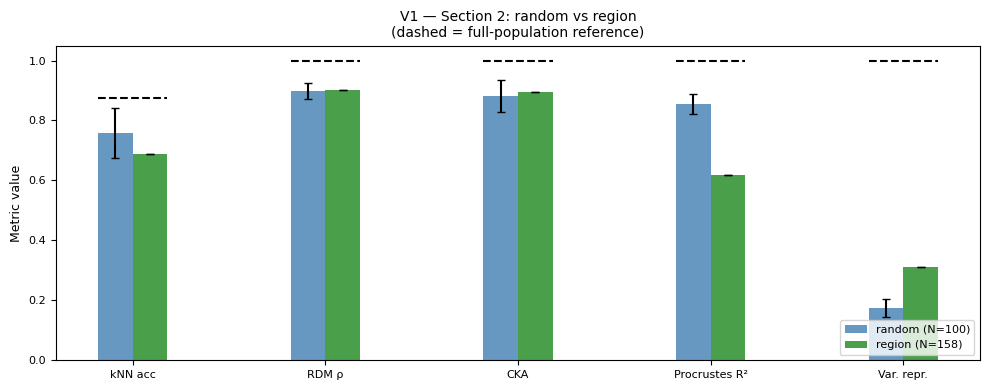

(<Figure size 1000x400 with 1 Axes>,
 <Axes: title={'center': 'V1 — Section 2: random vs region\n(dashed = full-population reference)'}, ylabel='Metric value'>)

In [25]:
# Compare region-selection to same-size random selection
k_region = len(idx_region)
results_rand_matched = []
for seed in range(N_TRIALS):
    rng = np.random.default_rng(seed + 100)
    idx = rng.choice(N_nonout, size=k_region, replace=False)
    results_rand_matched.append(
        evaluate_subpop(idx, label=f'random N={k_region} seed={seed}', show_plot=False))

print(f'\n--- Comparison at N={k_region} ---')
print(f"{'metric':6s}  {'region':>8s}  {'random (mean±std)':>20s}")
for key in ['acc', 'rdm', 'cka', 'r2']:
    rv = [r[key] for r in results_rand_matched]
    print(f"{key:6s}  {r_region[key]:8.3f}  "
          f"{np.nanmean(rv):8.3f} ± {np.nanstd(rv):.3f}")

# Cumulative metric comparison after Section 2
plot_metrics_bar(
    conditions=[
        (f'random (N={N_SAMPLE})',      results_random, 'steelblue'),
        (f'region (N={r_region["n"]})', [r_region],     'forestgreen'),
    ],
    title='Section 2: random vs region',
    save_suffix='metrics_s2_region',
)


In [26]:
# Scan multiple regions — top / bottom / middle thirds along each of first 3 DCs
print(f"\n--- Region sweep: top/mid/bot 1/3 along each DC ---")
print(f"{'region':40s}  {'N':>5s}  {'acc':>6s}  {'rdm':>6s}")
for dc in range(3):
    vals = embedding_full[:, dc]
    lo, hi = np.percentile(vals, [33, 67])
    regions = [
        (f'DC{dc} top 1/3',    vals > hi),
        (f'DC{dc} mid 1/3',    (vals >= lo) & (vals <= hi)),
        (f'DC{dc} bot 1/3',    vals < lo),
    ]
    for lbl, mask in regions:
        idx = np.where(mask)[0]
        tensor_sub = tensor4d_NSDT[idx]
        coords_sub, _ = compute_decoding_manifold(tensor_sub)
        acc = knn_decoding_accuracy(coords_sub, stim_labels)
        rdm = rdm_correlation(tensor4d_NSDT, tensor_sub)
        print(f"{lbl:40s}  {len(idx):>5d}  {acc:>6.3f}  {rdm:>6.3f}")


--- Region sweep: top/mid/bot 1/3 along each DC ---
region                                        N     acc     rdm
DC0 top 1/3                                 208   0.833   0.910
DC0 mid 1/3                                 214   0.771   0.912
DC0 bot 1/3                                 208   0.771   0.935
DC1 top 1/3                                 208   0.708   0.637
DC1 mid 1/3                                 214   0.812   0.917
DC1 bot 1/3                                 208   0.792   0.981
DC2 top 1/3                                 208   0.708   0.923
DC2 mid 1/3                                 214   0.667   0.720
DC1 mid 1/3                                 214   0.812   0.917
DC1 bot 1/3                                 208   0.792   0.981
DC2 top 1/3                                 208   0.708   0.923
DC2 mid 1/3                                 214   0.667   0.720
DC2 bot 1/3                                 208   0.646   0.961
DC2 bot 1/3                                 208   0

## 3 — Synthetic Clustered Manifold

**Key experiment.**

Construct a new population of ≈N neurons with **clustered** encoding manifold topology, while keeping per-stimulus responses locally realistic (shuffled from manifold neighbours).  

**Hypothesis:** Decoding metrics (kNN, RDM ρ, CKA) are preserved, but the encoding manifold shows discrete clusters instead of V1's smooth tubular structure.

In [27]:
# ─── PARAMETERS ──────────────────────────────────────────────────────────────
N_SEEDS     = 20   # number of clusters (seeds) in synthetic manifold
N_NEIGHBORS = 8    # neighbourhood size for per-stimulus response shuffling
RNG_SEED    = 42
# ─────────────────────────────────────────────────────────────────────────────

t0 = time.time()
tensor4d_synthetic = create_synthetic_clustered_population(
    tensor4d_NSDT, embedding_full,
    n_seeds=N_SEEDS, n_neighbors=N_NEIGHBORS, rng_seed=RNG_SEED
)
N_synth = len(tensor4d_synthetic)
print(f'Synthetic population: N={N_synth} (real N={N_nonout})  [{time.time()-t0:.1f}s]')
print(f'Shape: {tensor4d_synthetic.shape}')

Synthetic population: N=620 (real N=630)  [0.1s]
Shape: (620, 6, 8, 135)


In [28]:
# 3a — Decoding metrics for synthetic population
coords_synth, _ = compute_decoding_manifold(tensor4d_synthetic)

acc_synth = knn_decoding_accuracy(coords_synth, stim_labels)
rdm_synth = rdm_correlation(tensor4d_NSDT, tensor4d_synthetic)
cka_synth = linear_cka(tensor4d_NSDT, tensor4d_synthetic)
r2_synth  = procrustes_r2(coords_full, coords_synth)
var_synth = variance_reproduced(coords_full, coords_synth)

r2_str  = f'{r2_synth:.3f}'  if (r2_synth  is not None and not np.isnan(r2_synth))  else ' nan'
var_str = f'{var_synth:.3f}' if (var_synth is not None and not np.isnan(var_synth)) else ' nan'

print('Decoding metrics:')
print(f"{'population':30s}  {'kNN':>6s}  {'RDM \u03c1':>7s}  {'CKA':>6s}  {'R\u00b2':>6s}  {'var':>6s}")
print(f"{'V1 full (reference)':30s}  {acc_full:6.3f}  {'1.000':>7s}  {'1.000':>6s}  {'1.000':>6s}  {'1.000':>6s}")
print(f"{'synthetic (clustered)':30s}  {acc_synth:6.3f}  {rdm_synth:7.3f}  {cka_synth:6.3f}  "
      f"{r2_str:>6s}  {var_str:>6s}")


Decoding metrics:
population                         kNN    RDM ρ     CKA      R²     var
V1 full (reference)              0.875    1.000   1.000   1.000   1.000
synthetic (clustered)            1.000    0.847   0.876   0.842   2.173


Building encoding manifold for real population (direct-PCA pipeline)...
### Iteration 1 done. (0.15 s) - pruned 1 edge(s)
### Iteration 2 done. (0.02 s) - pruned 1 edge(s)
### Iteration 1 done. (0.15 s) - pruned 1 edge(s)
### Iteration 2 done. (0.02 s) - pruned 1 edge(s)
### Iteration 3 done. (0.02 s) - pruned 1 edge(s)
CONVERGED: no change in unweighted graph.
Total # edges pruned: 3, (0 disconnected points)
C-tuning weighted graph...
Unweighted graph stats: mean=1.146, median=1.078
Weighted graph stats: mean=1.046, median=1.009
### Iteration 3 done. (0.02 s) - pruned 1 edge(s)
CONVERGED: no change in unweighted graph.
Total # edges pruned: 3, (0 disconnected points)
C-tuning weighted graph...
Unweighted graph stats: mean=1.146, median=1.078
Weighted graph stats: mean=1.046, median=1.009


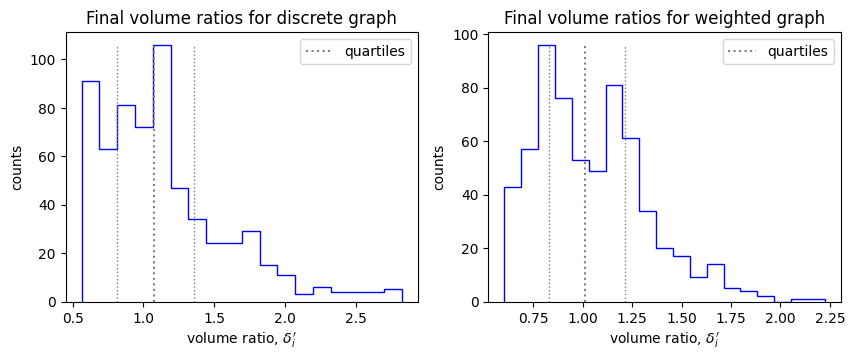

  done in 0.5s  N_clean=623  nPCs=1


In [29]:
# 3b — Encoding manifold of real population via direct-PCA pipeline
#      (same method as synthetic for a fair comparison)
print('Building encoding manifold for real population (direct-PCA pipeline)...')
t0 = time.time()
enc_real = compute_encoding_manifold_from_tensor(tensor4d_NSDT)
print(f'  done in {time.time()-t0:.1f}s  '
      f'N_clean={len(enc_real["nonoutliers"])}  nPCs={enc_real["nPCs"]}')

Building encoding manifold for synthetic population...
### Iteration 1 done. (0.22 s) - pruned 3 edge(s)
### Iteration 2 done. (0.06 s) - pruned 3 edge(s)
### Iteration 3 done. (0.06 s) - pruned 3 edge(s)
### Iteration 4 done. (0.06 s) - pruned 2 edge(s)
### Iteration 1 done. (0.22 s) - pruned 3 edge(s)
### Iteration 2 done. (0.06 s) - pruned 3 edge(s)
### Iteration 3 done. (0.06 s) - pruned 3 edge(s)
### Iteration 4 done. (0.06 s) - pruned 2 edge(s)
### Iteration 5 done. (0.06 s) - pruned 2 edge(s)
### Iteration 6 done. (0.06 s) - pruned 2 edge(s)
### Iteration 7 done. (0.06 s) - pruned 2 edge(s)
### Iteration 8 done. (0.06 s) - pruned 2 edge(s)
### Iteration 5 done. (0.06 s) - pruned 2 edge(s)
### Iteration 6 done. (0.06 s) - pruned 2 edge(s)
### Iteration 7 done. (0.06 s) - pruned 2 edge(s)
### Iteration 8 done. (0.06 s) - pruned 2 edge(s)
### Iteration 9 done. (0.06 s) - pruned 2 edge(s)
### Iteration 10 done. (0.06 s) - pruned 2 edge(s)
### Iteration 11 done. (0.06 s) - pruned 2 e

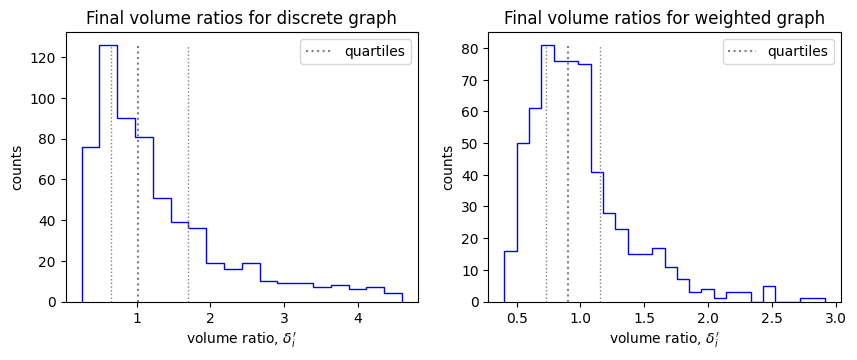

  done in 3.9s  N_clean=613  nPCs=4


In [30]:
# 3c — Encoding manifold of synthetic population
print('Building encoding manifold for synthetic population...')
t0 = time.time()
enc_synth = compute_encoding_manifold_from_tensor(tensor4d_synthetic)
print(f'  done in {time.time()-t0:.1f}s  '
      f'N_clean={len(enc_synth["nonoutliers"])}  nPCs={enc_synth["nPCs"]}')

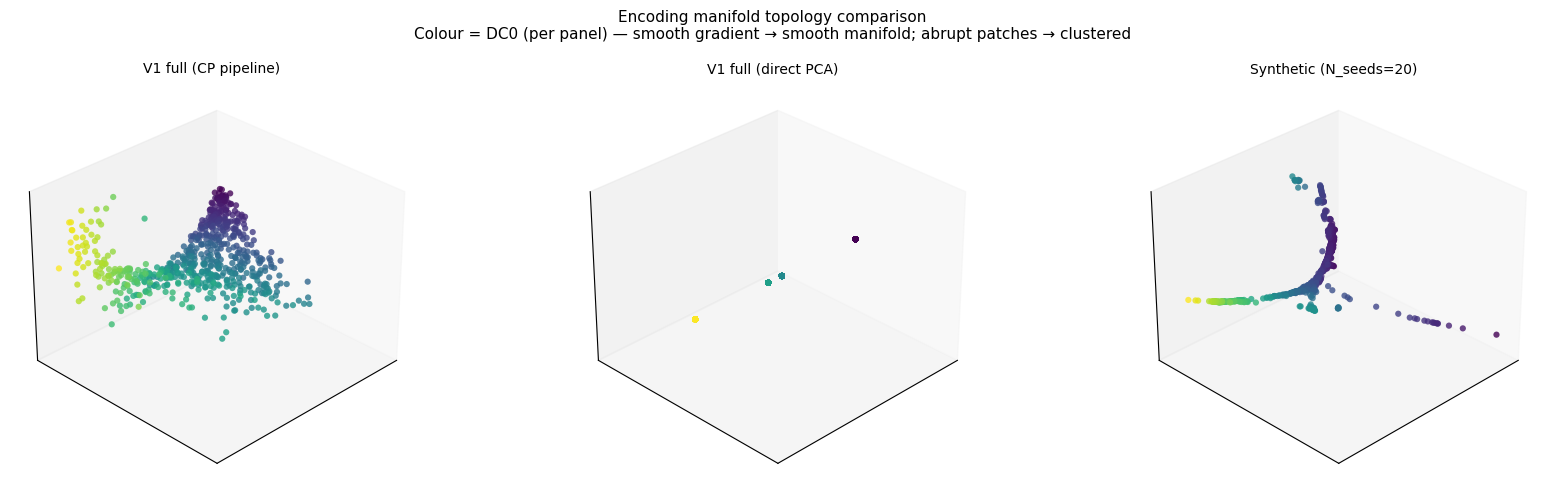

In [31]:
# 3d — Side-by-side comparison: V1 (standard) | V1 (direct PCA) | Synthetic
#
# Colour by DC0 value (continuous, per-panel normalised).
# Smooth manifold → gradual colour gradient; clustered → abrupt colour patches.
# run_hdbscan_clustering is NOT used here because it requires diffmap_y + nPCs + G;
# load_for_explorer does not return those for the full-population panel.

from matplotlib.colors import Normalize

fig = plt.figure(figsize=(17, 5))
cmap_enc = plt.cm.viridis

panels = [
    (embedding_full,           'V1 full (CP pipeline)'),
    (enc_real['embedding_'],   'V1 full (direct PCA)'),
    (enc_synth['embedding_'],  f'Synthetic (N_seeds={N_SEEDS})'),
]
for pi, (emb, title) in enumerate(panels):
    ax = fig.add_subplot(1, 3, pi + 1, projection='3d')
    dc0  = emb[:, 0]
    norm = Normalize(vmin=dc0.min(), vmax=dc0.max())
    ax.scatter(emb[:, 0], emb[:, 1], emb[:, 2],
               c=cmap_enc(norm(dc0)), s=20, alpha=0.8,
               edgecolors='none', depthshade=False)
    ax.set_xticks([]); ax.set_yticks([]); ax.set_zticks([])
    ax.view_init(elev=30, azim=45)
    ax.set_title(title, fontsize=10)

fig.suptitle(
    'Encoding manifold topology comparison\n'
    'Colour = DC0 (per panel) — smooth gradient → smooth manifold; '
    'abrupt patches → clustered',
    fontsize=11)
plt.tight_layout()
plt.savefig(f'{BASEDIR_FIG}/{PREFIX}_encoding_comparison_N{N_SEEDS}seeds.pdf',
            bbox_inches='tight')
plt.show()


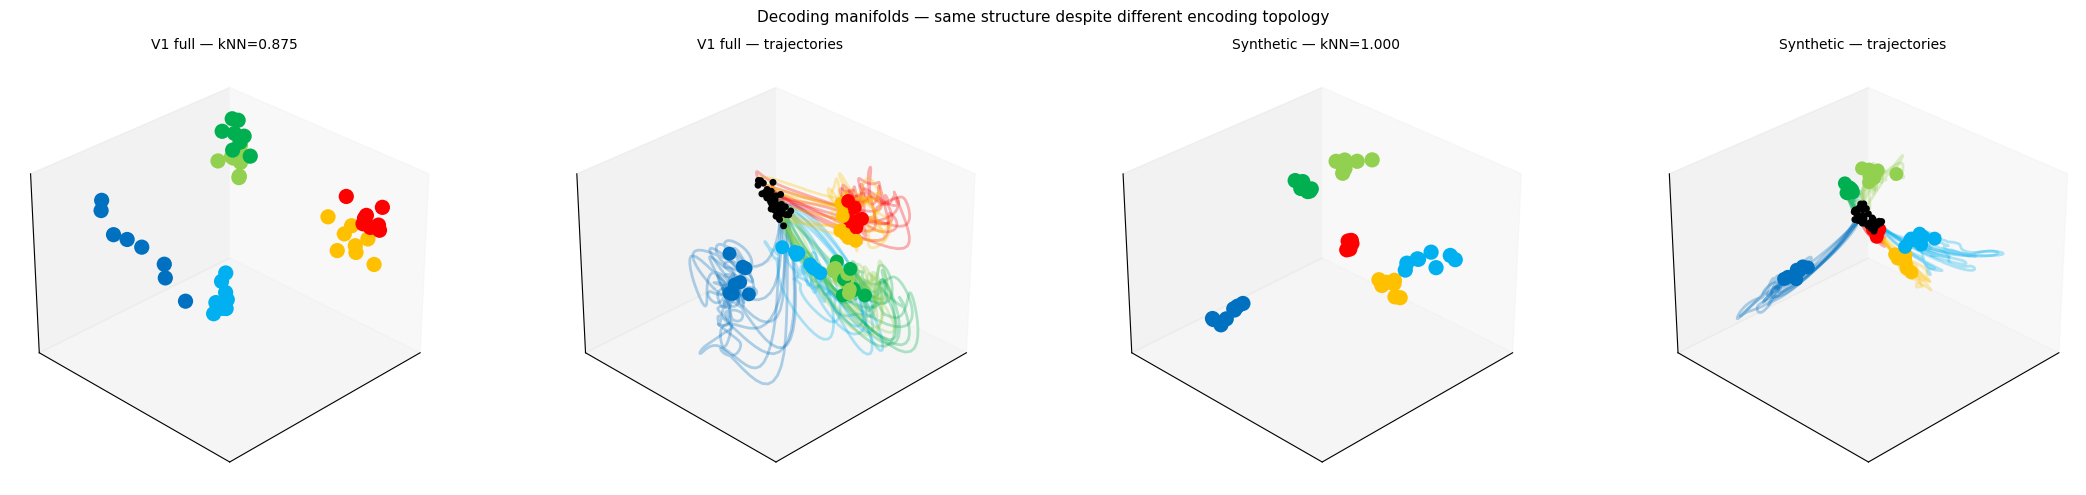

In [32]:
# 3e — Decoding manifold + trajectory comparison: V1 full vs synthetic
trajs_full,  _ = compute_decoding_trajectories(tensor4d_NSDT)
trajs_synth, _ = compute_decoding_trajectories(tensor4d_synthetic)

fig = plt.figure(figsize=(22, 5))
panels = [
    (coords_full,  trajs_full,  f'V1 full — kNN={acc_full:.3f}'),
    (coords_synth, trajs_synth, f'Synthetic — kNN={acc_synth:.3f}'),
]
for pi, (coords, trajs, title) in enumerate(panels):
    # Decoding manifold
    ax_m = fig.add_subplot(1, 4, pi * 2 + 1, projection='3d')
    for si in range(NSTIMS):
        sel = stim_labels == si
        ax_m.scatter(coords[sel, 0], coords[sel, 1], coords[sel, 2],
                     c=STIM_COLORS[si % len(STIM_COLORS)], s=120, alpha=1.0,
                     edgecolors='none', depthshade=False)
    ax_m.set_xticks([]); ax_m.set_yticks([]); ax_m.set_zticks([])
    ax_m.view_init(elev=30, azim=45)
    ax_m.set_title(title, fontsize=10)

    # Decoding trajectories
    ax_t = fig.add_subplot(1, 4, pi * 2 + 2, projection='3d')
    for i, traj in enumerate(trajs):
        si = i // NDIRS
        col = STIM_COLORS[si % len(STIM_COLORS)]
        valid = ~np.any(np.isnan(traj), axis=1)
        tv = traj[valid]
        if len(tv) < 2:
            continue
        ax_t.plot(tv[:, 0], tv[:, 1], tv[:, 2],
                  color=col, linewidth=2, alpha=0.3)
        ax_t.scatter(tv[0, 0], tv[0, 1], tv[0, 2],
                     color='black', s=25, edgecolors='none', depthshade=False)
        ax_t.scatter(tv[-1, 0], tv[-1, 1], tv[-1, 2],
                     color=col, s=100, edgecolors='none', depthshade=False)
    ax_t.set_xticks([]); ax_t.set_yticks([]); ax_t.set_zticks([])
    ax_t.view_init(elev=30, azim=45)
    ax_t.set_title(f'{title.split("—")[0].strip()} — trajectories', fontsize=10)

fig.suptitle('Decoding manifolds — same structure despite different encoding topology',
             fontsize=11)
plt.tight_layout()
plt.savefig(f'{BASEDIR_FIG}/{PREFIX}_decoding_comparison.pdf', bbox_inches='tight')
plt.show()

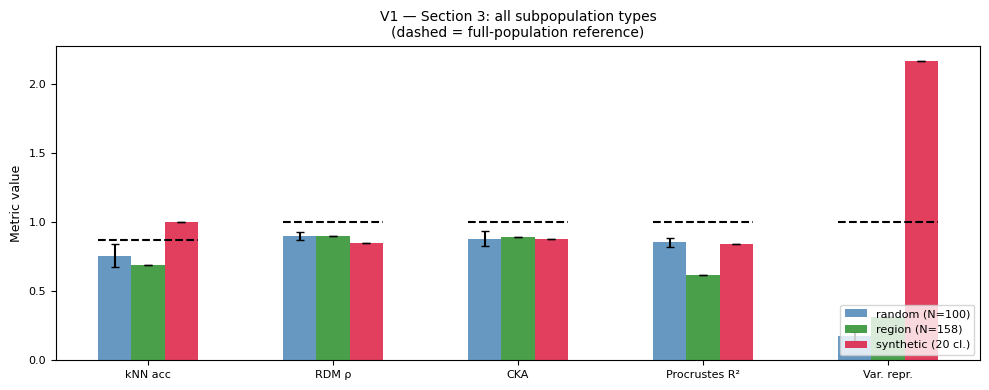

SUMMARY
Population                            N      kNN    RDM ρ      CKA       R²      var
------------------------------------------------------------------------------------
V1 full (reference)                 630    0.875    1.000    1.000    1.000    1.000
random N=100                        100    0.758    0.900    0.882    0.856    0.174
region N=158                        158    0.688    0.903    0.896    0.618    0.312
synthetic 20 clusters               620    1.000    0.847    0.876    0.842    2.173


In [33]:
# 3f \u2014 Final comparison: all conditions including synthetic

# Build synthetic result dict from computed scalars
result_synthetic = dict(acc=acc_synth, rdm=rdm_synth, cka=cka_synth,
                        r2=r2_synth, var=var_synth, n=N_synth)

plot_metrics_bar(
    conditions=[
        (f'random (N={N_SAMPLE})',       results_random,     'steelblue'),
        (f'region (N={r_region["n"]})',  [r_region],         'forestgreen'),
        (f'synthetic ({N_SEEDS} cl.)',   [result_synthetic], 'crimson'),
    ],
    title='Section 3: all subpopulation types',
    save_suffix='metrics_s3_all',
)

# Text table
metric_keys   = ['acc', 'rdm', 'cka', 'r2', 'var']
metric_labels = ['kNN', 'RDM \u03c1', 'CKA', 'R\u00b2', 'var']
all_conds = [
    ('V1 full (reference)',          [dict(acc=acc_full, rdm=1., cka=1., r2=1., var=1.)], N_nonout),
    (f'random N={N_SAMPLE}',         results_random,   N_SAMPLE),
    (f'region N={r_region["n"]}',    [r_region],       r_region['n']),
    (f'synthetic {N_SEEDS} clusters',[result_synthetic],N_synth),
]
hdr = f"{'Population':32s}  {'N':>5s}" + ''.join(f'  {m:>7s}' for m in metric_labels)
print('='*len(hdr)); print('SUMMARY'); print('='*len(hdr)); print(hdr); print('-'*len(hdr))
for lbl, res_list, N_val in all_conds:
    row = f'{lbl:32s}  {N_val:>5d}'
    for k in metric_keys:
        vals = [r[k] for r in res_list
                if r.get(k) is not None and not np.isnan(r.get(k, np.nan))]
        row += f'  {np.nanmean(vals):7.3f}' if vals else f'  {"nan":>7s}'
    print(row)
print('='*len(hdr))


## 4 — Parameter Sweep: N_seeds × N_neighbors (optional)

Varies `N_SEEDS` and `N_NEIGHBORS` to find the regime where decoding is preserved but encoding topology is maximally clustered.

  N_seeds=  5  N_nbrs=  3  SKIPPED (ValueError: Nearly identical points found (np.isclose(distance,0) == True). Please remove duplicates before running the algorithm.)
### Iteration 1 done. (0.33 s) - pruned 6 edge(s)
### Iteration 2 done. (0.06 s) - pruned 6 edge(s)
### Iteration 3 done. (0.06 s) - pruned 5 edge(s)
### Iteration 4 done. (0.05 s) - pruned 5 edge(s)
### Iteration 1 done. (0.33 s) - pruned 6 edge(s)
### Iteration 2 done. (0.06 s) - pruned 6 edge(s)
### Iteration 3 done. (0.06 s) - pruned 5 edge(s)
### Iteration 4 done. (0.05 s) - pruned 5 edge(s)
### Iteration 5 done. (0.06 s) - pruned 5 edge(s)
### Iteration 6 done. (0.06 s) - pruned 5 edge(s)
### Iteration 5 done. (0.06 s) - pruned 5 edge(s)
### Iteration 6 done. (0.06 s) - pruned 5 edge(s)
### Iteration 7 done. (0.52 s) - pruned 6 edge(s)
### Iteration 8 done. (0.06 s) - pruned 6 edge(s)
### Iteration 9 done. (0.06 s) - pruned 6 edge(s)
### Iteration 10 done. (0.05 s) - pruned 5 edge(s)
### Iteration 7 done. (0.52 s) 

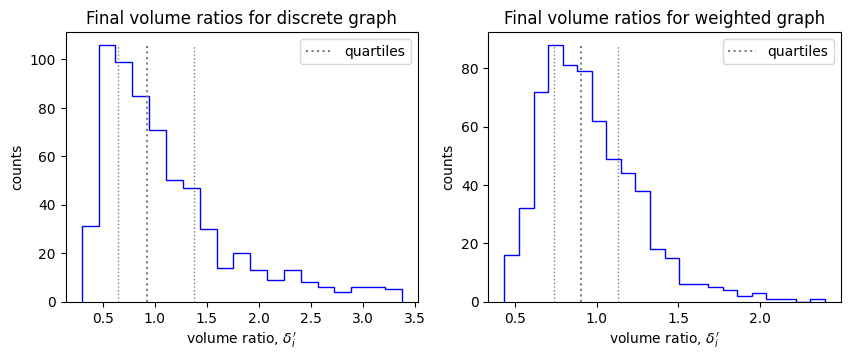

  N_seeds=  5  N_nbrs=  5  kNN=1.000  RDM=0.172  CKA=0.498  DB=0.12
### Iteration 1 done. (0.27 s) - pruned 5 edge(s)
### Iteration 2 done. (0.06 s) - pruned 5 edge(s)
### Iteration 3 done. (0.05 s) - pruned 5 edge(s)
### Iteration 4 done. (0.06 s) - pruned 5 edge(s)
### Iteration 1 done. (0.27 s) - pruned 5 edge(s)
### Iteration 2 done. (0.06 s) - pruned 5 edge(s)
### Iteration 3 done. (0.05 s) - pruned 5 edge(s)
### Iteration 4 done. (0.06 s) - pruned 5 edge(s)
### Iteration 5 done. (0.05 s) - pruned 5 edge(s)
### Iteration 6 done. (0.06 s) - pruned 4 edge(s)
### Iteration 7 done. (0.05 s) - pruned 4 edge(s)
### Iteration 8 done. (0.06 s) - pruned 4 edge(s)
### Iteration 5 done. (0.05 s) - pruned 5 edge(s)
### Iteration 6 done. (0.06 s) - pruned 4 edge(s)
### Iteration 7 done. (0.05 s) - pruned 4 edge(s)
### Iteration 8 done. (0.06 s) - pruned 4 edge(s)
### Iteration 9 done. (0.49 s) - pruned 5 edge(s)
### Iteration 10 done. (0.06 s) - pruned 4 edge(s)
### Iteration 11 done. (0.05 s)

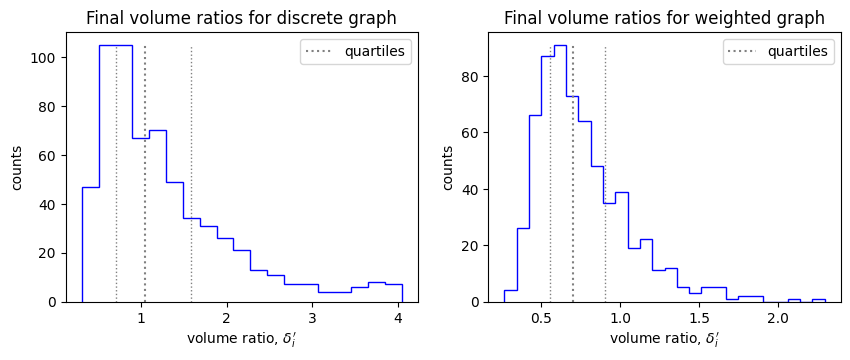

  N_seeds=  5  N_nbrs=  8  kNN=0.938  RDM=0.145  CKA=0.474  DB=0.00
### Iteration 1 done. (0.41 s) - pruned 3 edge(s)
### Iteration 2 done. (0.06 s) - pruned 3 edge(s)
### Iteration 3 done. (0.06 s) - pruned 3 edge(s)
### Iteration 4 done. (0.06 s) - pruned 3 edge(s)
### Iteration 1 done. (0.41 s) - pruned 3 edge(s)
### Iteration 2 done. (0.06 s) - pruned 3 edge(s)
### Iteration 3 done. (0.06 s) - pruned 3 edge(s)
### Iteration 4 done. (0.06 s) - pruned 3 edge(s)
### Iteration 5 done. (0.07 s) - pruned 3 edge(s)
### Iteration 6 done. (0.06 s) - pruned 3 edge(s)
### Iteration 7 done. (0.06 s) - pruned 3 edge(s)
### Iteration 8 done. (0.06 s) - pruned 3 edge(s)
### Iteration 5 done. (0.07 s) - pruned 3 edge(s)
### Iteration 6 done. (0.06 s) - pruned 3 edge(s)
### Iteration 7 done. (0.06 s) - pruned 3 edge(s)
### Iteration 8 done. (0.06 s) - pruned 3 edge(s)
### Iteration 9 done. (0.06 s) - pruned 3 edge(s)
### Iteration 10 done. (0.06 s) - pruned 3 edge(s)
### Iteration 11 done. (0.06 s)

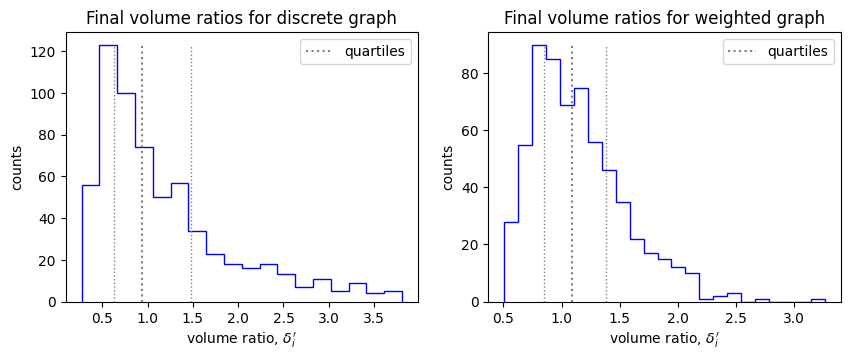

  N_seeds=  5  N_nbrs= 15  kNN=0.979  RDM=0.196  CKA=0.526  DB=0.35
  N_seeds= 10  N_nbrs=  3  SKIPPED (ValueError: Nearly identical points found (np.isclose(distance,0) == True). Please remove duplicates before running the algorithm.)
### Iteration 1 done. (0.29 s) - pruned 2 edge(s)
### Iteration 2 done. (0.06 s) - pruned 2 edge(s)
### Iteration 3 done. (0.06 s) - pruned 2 edge(s)
### Iteration 4 done. (0.06 s) - pruned 2 edge(s)
### Iteration 1 done. (0.29 s) - pruned 2 edge(s)
### Iteration 2 done. (0.06 s) - pruned 2 edge(s)
### Iteration 3 done. (0.06 s) - pruned 2 edge(s)
### Iteration 4 done. (0.06 s) - pruned 2 edge(s)
### Iteration 5 done. (0.06 s) - pruned 2 edge(s)
### Iteration 6 done. (0.06 s) - pruned 2 edge(s)
### Iteration 7 done. (0.06 s) - pruned 2 edge(s)
### Iteration 8 done. (0.06 s) - pruned 2 edge(s)
### Iteration 5 done. (0.06 s) - pruned 2 edge(s)
### Iteration 6 done. (0.06 s) - pruned 2 edge(s)
### Iteration 7 done. (0.06 s) - pruned 2 edge(s)
### Iteration 

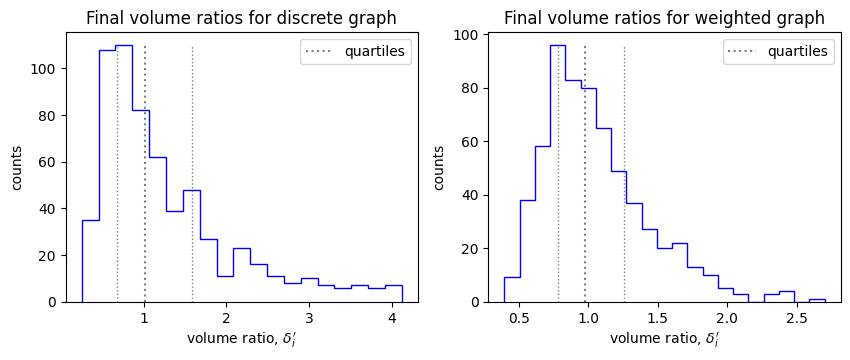

  N_seeds= 10  N_nbrs=  5  kNN=0.896  RDM=0.821  CKA=0.857  DB=nan
### Iteration 1 done. (0.26 s) - pruned 4 edge(s)
### Iteration 2 done. (0.06 s) - pruned 3 edge(s)
### Iteration 3 done. (0.05 s) - pruned 3 edge(s)
### Iteration 4 done. (0.05 s) - pruned 3 edge(s)
### Iteration 1 done. (0.26 s) - pruned 4 edge(s)
### Iteration 2 done. (0.06 s) - pruned 3 edge(s)
### Iteration 3 done. (0.05 s) - pruned 3 edge(s)
### Iteration 4 done. (0.05 s) - pruned 3 edge(s)
### Iteration 5 done. (0.06 s) - pruned 3 edge(s)
### Iteration 6 done. (0.05 s) - pruned 3 edge(s)
### Iteration 7 done. (0.05 s) - pruned 3 edge(s)
### Iteration 5 done. (0.06 s) - pruned 3 edge(s)
### Iteration 6 done. (0.05 s) - pruned 3 edge(s)
### Iteration 7 done. (0.05 s) - pruned 3 edge(s)
### Iteration 8 done. (0.66 s) - pruned 3 edge(s)
### Iteration 9 done. (0.05 s) - pruned 3 edge(s)
### Iteration 10 done. (0.05 s) - pruned 3 edge(s)
### Iteration 11 done. (0.05 s) - pruned 3 edge(s)
### Iteration 8 done. (0.66 s) 

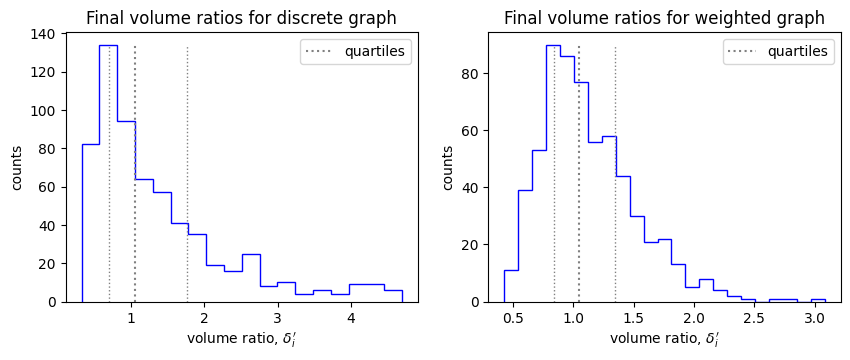

  N_seeds= 10  N_nbrs=  8  kNN=0.917  RDM=0.750  CKA=0.817  DB=0.21
### Iteration 1 done. (0.37 s) - pruned 3 edge(s)
### Iteration 2 done. (0.09 s) - pruned 3 edge(s)
### Iteration 3 done. (0.09 s) - pruned 2 edge(s)
### Iteration 1 done. (0.37 s) - pruned 3 edge(s)
### Iteration 2 done. (0.09 s) - pruned 3 edge(s)
### Iteration 3 done. (0.09 s) - pruned 2 edge(s)
### Iteration 4 done. (0.09 s) - pruned 2 edge(s)
### Iteration 5 done. (0.08 s) - pruned 2 edge(s)
### Iteration 6 done. (0.08 s) - pruned 2 edge(s)
### Iteration 4 done. (0.09 s) - pruned 2 edge(s)
### Iteration 5 done. (0.08 s) - pruned 2 edge(s)
### Iteration 6 done. (0.08 s) - pruned 2 edge(s)
### Iteration 7 done. (0.08 s) - pruned 2 edge(s)
### Iteration 8 done. (0.08 s) - pruned 2 edge(s)
### Iteration 9 done. (0.08 s) - pruned 2 edge(s)
### Iteration 7 done. (0.08 s) - pruned 2 edge(s)
### Iteration 8 done. (0.08 s) - pruned 2 edge(s)
### Iteration 9 done. (0.08 s) - pruned 2 edge(s)
### Iteration 10 done. (0.08 s) 

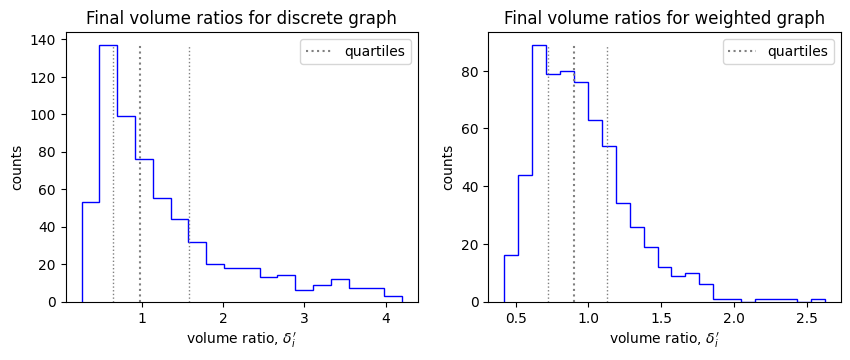

  N_seeds= 10  N_nbrs= 15  kNN=1.000  RDM=0.781  CKA=0.865  DB=0.16
  N_seeds= 20  N_nbrs=  3  SKIPPED (ValueError: Nearly identical points found (np.isclose(distance,0) == True). Please remove duplicates before running the algorithm.)
### Iteration 1 done. (0.31 s) - pruned 5 edge(s)
### Iteration 2 done. (0.06 s) - pruned 5 edge(s)
### Iteration 3 done. (0.05 s) - pruned 4 edge(s)
### Iteration 4 done. (0.05 s) - pruned 4 edge(s)
### Iteration 1 done. (0.31 s) - pruned 5 edge(s)
### Iteration 2 done. (0.06 s) - pruned 5 edge(s)
### Iteration 3 done. (0.05 s) - pruned 4 edge(s)
### Iteration 4 done. (0.05 s) - pruned 4 edge(s)
### Iteration 5 done. (0.06 s) - pruned 4 edge(s)
### Iteration 6 done. (0.05 s) - pruned 4 edge(s)
### Iteration 7 done. (0.05 s) - pruned 3 edge(s)
### Iteration 8 done. (0.05 s) - pruned 3 edge(s)
### Iteration 5 done. (0.06 s) - pruned 4 edge(s)
### Iteration 6 done. (0.05 s) - pruned 4 edge(s)
### Iteration 7 done. (0.05 s) - pruned 3 edge(s)
### Iteration 

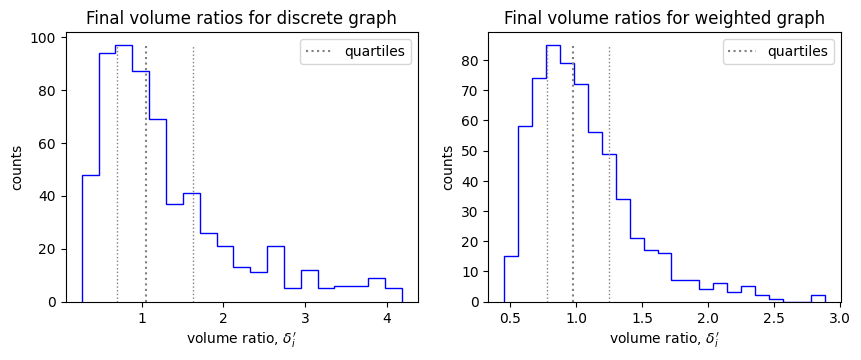

  N_seeds= 20  N_nbrs=  5  kNN=0.917  RDM=0.863  CKA=0.914  DB=1.33
### Iteration 1 done. (0.25 s) - pruned 3 edge(s)
### Iteration 2 done. (0.06 s) - pruned 3 edge(s)
### Iteration 3 done. (0.06 s) - pruned 3 edge(s)
### Iteration 4 done. (0.06 s) - pruned 2 edge(s)
### Iteration 1 done. (0.25 s) - pruned 3 edge(s)
### Iteration 2 done. (0.06 s) - pruned 3 edge(s)
### Iteration 3 done. (0.06 s) - pruned 3 edge(s)
### Iteration 4 done. (0.06 s) - pruned 2 edge(s)
### Iteration 5 done. (0.06 s) - pruned 2 edge(s)
### Iteration 6 done. (0.06 s) - pruned 2 edge(s)
### Iteration 7 done. (0.06 s) - pruned 2 edge(s)
### Iteration 8 done. (0.06 s) - pruned 2 edge(s)
### Iteration 5 done. (0.06 s) - pruned 2 edge(s)
### Iteration 6 done. (0.06 s) - pruned 2 edge(s)
### Iteration 7 done. (0.06 s) - pruned 2 edge(s)
### Iteration 8 done. (0.06 s) - pruned 2 edge(s)
### Iteration 9 done. (0.06 s) - pruned 2 edge(s)
### Iteration 10 done. (0.05 s) - pruned 2 edge(s)
### Iteration 11 done. (0.05 s)

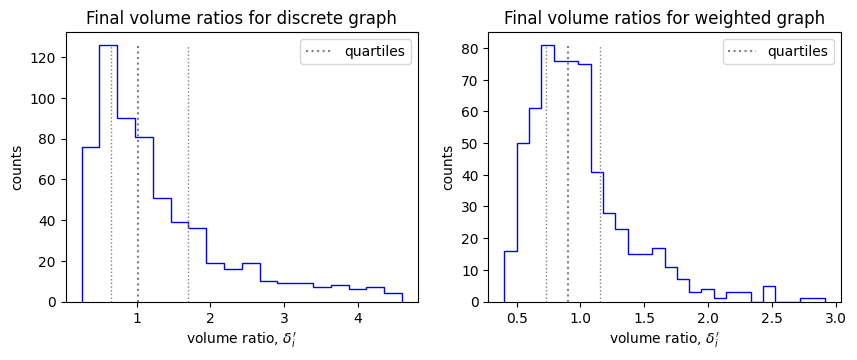

  N_seeds= 20  N_nbrs=  8  kNN=1.000  RDM=0.847  CKA=0.876  DB=nan
### Iteration 1 done. (0.42 s) - pruned 3 edge(s)
### Iteration 2 done. (0.08 s) - pruned 3 edge(s)
### Iteration 3 done. (0.08 s) - pruned 3 edge(s)
### Iteration 1 done. (0.42 s) - pruned 3 edge(s)
### Iteration 2 done. (0.08 s) - pruned 3 edge(s)
### Iteration 3 done. (0.08 s) - pruned 3 edge(s)
### Iteration 4 done. (0.07 s) - pruned 3 edge(s)
### Iteration 5 done. (0.07 s) - pruned 3 edge(s)
### Iteration 6 done. (0.08 s) - pruned 3 edge(s)
### Iteration 4 done. (0.07 s) - pruned 3 edge(s)
### Iteration 5 done. (0.07 s) - pruned 3 edge(s)
### Iteration 6 done. (0.08 s) - pruned 3 edge(s)
### Iteration 7 done. (0.08 s) - pruned 3 edge(s)
### Iteration 8 done. (0.08 s) - pruned 3 edge(s)
### Iteration 9 done. (0.07 s) - pruned 3 edge(s)
### Iteration 7 done. (0.08 s) - pruned 3 edge(s)
### Iteration 8 done. (0.08 s) - pruned 3 edge(s)
### Iteration 9 done. (0.07 s) - pruned 3 edge(s)
### Iteration 10 done. (0.08 s) -

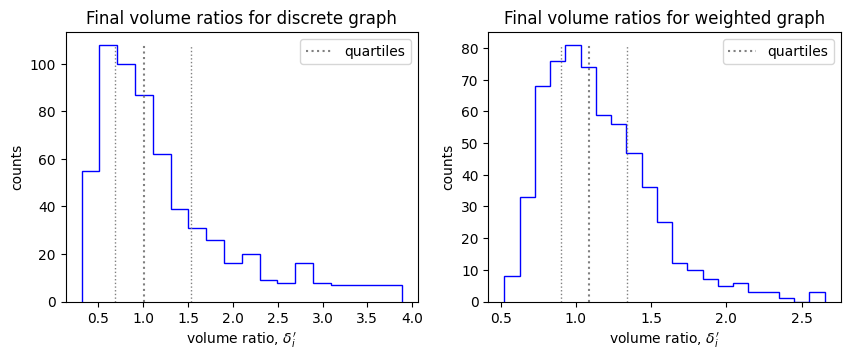

  N_seeds= 20  N_nbrs= 15  kNN=1.000  RDM=0.791  CKA=0.876  DB=nan
  N_seeds= 30  N_nbrs=  3  SKIPPED (ValueError: Nearly identical points found (np.isclose(distance,0) == True). Please remove duplicates before running the algorithm.)
### Iteration 1 done. (0.31 s) - pruned 2 edge(s)
### Iteration 2 done. (0.07 s) - pruned 2 edge(s)
### Iteration 3 done. (0.07 s) - pruned 2 edge(s)
### Iteration 1 done. (0.31 s) - pruned 2 edge(s)
### Iteration 2 done. (0.07 s) - pruned 2 edge(s)
### Iteration 3 done. (0.07 s) - pruned 2 edge(s)
### Iteration 4 done. (0.07 s) - pruned 2 edge(s)
### Iteration 5 done. (0.07 s) - pruned 2 edge(s)
### Iteration 6 done. (0.07 s) - pruned 2 edge(s)
### Iteration 4 done. (0.07 s) - pruned 2 edge(s)
### Iteration 5 done. (0.07 s) - pruned 2 edge(s)
### Iteration 6 done. (0.07 s) - pruned 2 edge(s)
### Iteration 7 done. (0.08 s) - pruned 2 edge(s)
### Iteration 8 done. (0.07 s) - pruned 2 edge(s)
### Iteration 9 done. (0.07 s) - pruned 2 edge(s)
### Iteration 7

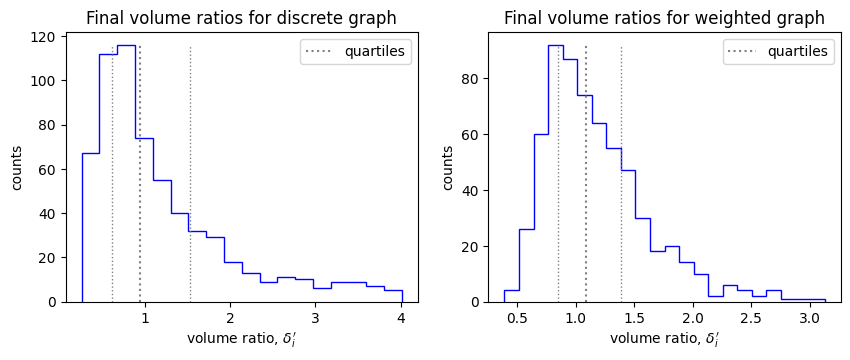

  N_seeds= 30  N_nbrs=  5  kNN=0.958  RDM=0.814  CKA=0.881  DB=nan
### Iteration 1 done. (0.32 s) - pruned 2 edge(s)
### Iteration 1 done. (0.32 s) - pruned 2 edge(s)
### Iteration 2 done. (0.69 s) - pruned 2 edge(s)
### Iteration 3 done. (0.08 s) - pruned 2 edge(s)
### Iteration 4 done. (0.07 s) - pruned 2 edge(s)
### Iteration 2 done. (0.69 s) - pruned 2 edge(s)
### Iteration 3 done. (0.08 s) - pruned 2 edge(s)
### Iteration 4 done. (0.07 s) - pruned 2 edge(s)
### Iteration 5 done. (0.08 s) - pruned 2 edge(s)
### Iteration 6 done. (0.07 s) - pruned 2 edge(s)
### Iteration 7 done. (0.07 s) - pruned 2 edge(s)
### Iteration 5 done. (0.08 s) - pruned 2 edge(s)
### Iteration 6 done. (0.07 s) - pruned 2 edge(s)
### Iteration 7 done. (0.07 s) - pruned 2 edge(s)
### Iteration 8 done. (0.07 s) - pruned 2 edge(s)
### Iteration 9 done. (0.08 s) - pruned 2 edge(s)
### Iteration 10 done. (0.08 s) - pruned 2 edge(s)
### Iteration 8 done. (0.07 s) - pruned 2 edge(s)
### Iteration 9 done. (0.08 s) -

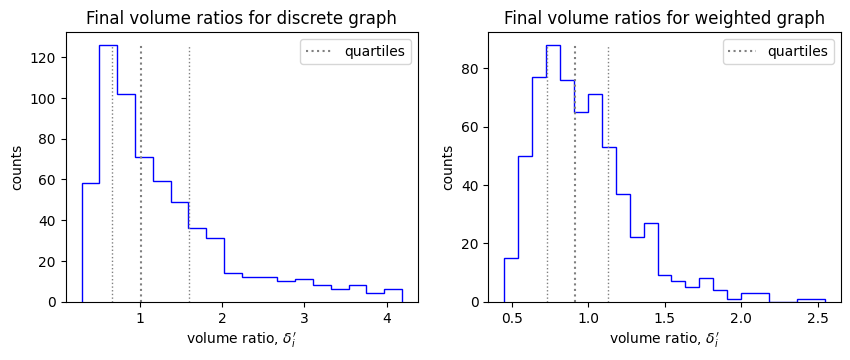

  N_seeds= 30  N_nbrs=  8  kNN=1.000  RDM=0.808  CKA=0.858  DB=0.23
### Iteration 1 done. (0.33 s) - pruned 3 edge(s)
### Iteration 2 done. (0.09 s) - pruned 3 edge(s)
### Iteration 3 done. (0.09 s) - pruned 3 edge(s)
### Iteration 1 done. (0.33 s) - pruned 3 edge(s)
### Iteration 2 done. (0.09 s) - pruned 3 edge(s)
### Iteration 3 done. (0.09 s) - pruned 3 edge(s)
### Iteration 4 done. (0.09 s) - pruned 3 edge(s)
### Iteration 5 done. (0.09 s) - pruned 2 edge(s)
### Iteration 6 done. (0.09 s) - pruned 2 edge(s)
### Iteration 4 done. (0.09 s) - pruned 3 edge(s)
### Iteration 5 done. (0.09 s) - pruned 2 edge(s)
### Iteration 6 done. (0.09 s) - pruned 2 edge(s)
### Iteration 7 done. (0.08 s) - pruned 2 edge(s)
### Iteration 8 done. (0.08 s) - pruned 2 edge(s)
### Iteration 9 done. (0.09 s) - pruned 2 edge(s)
### Iteration 7 done. (0.08 s) - pruned 2 edge(s)
### Iteration 8 done. (0.08 s) - pruned 2 edge(s)
### Iteration 9 done. (0.09 s) - pruned 2 edge(s)
### Iteration 10 done. (0.08 s) 

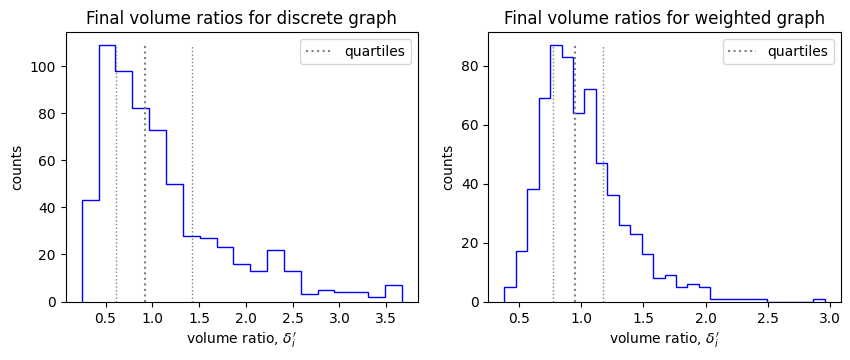

  N_seeds= 30  N_nbrs= 15  kNN=1.000  RDM=0.811  CKA=0.820  DB=nan
### Iteration 1 done. (0.23 s) - pruned 3 edge(s)
### Iteration 2 done. (0.05 s) - pruned 3 edge(s)
### Iteration 3 done. (0.05 s) - pruned 3 edge(s)
### Iteration 4 done. (0.05 s) - pruned 3 edge(s)
### Iteration 5 done. (0.05 s) - pruned 2 edge(s)
### Iteration 1 done. (0.23 s) - pruned 3 edge(s)
### Iteration 2 done. (0.05 s) - pruned 3 edge(s)
### Iteration 3 done. (0.05 s) - pruned 3 edge(s)
### Iteration 4 done. (0.05 s) - pruned 3 edge(s)
### Iteration 5 done. (0.05 s) - pruned 2 edge(s)
### Iteration 6 done. (0.05 s) - pruned 2 edge(s)
### Iteration 7 done. (0.05 s) - pruned 2 edge(s)
### Iteration 8 done. (0.05 s) - pruned 2 edge(s)
### Iteration 9 done. (0.05 s) - pruned 2 edge(s)
### Iteration 10 done. (0.04 s) - pruned 2 edge(s)
### Iteration 6 done. (0.05 s) - pruned 2 edge(s)
### Iteration 7 done. (0.05 s) - pruned 2 edge(s)
### Iteration 8 done. (0.05 s) - pruned 2 edge(s)
### Iteration 9 done. (0.05 s) -

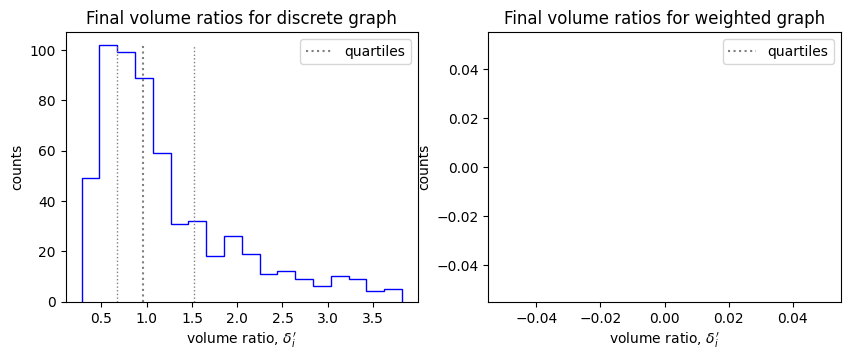

  N_seeds= 50  N_nbrs=  3  kNN=1.000  RDM=0.650  CKA=0.705  DB=0.41
### Iteration 1 done. (0.43 s) - pruned 2 edge(s)
### Iteration 2 done. (0.05 s) - pruned 2 edge(s)
### Iteration 3 done. (0.05 s) - pruned 2 edge(s)
### Iteration 4 done. (0.05 s) - pruned 2 edge(s)
### Iteration 1 done. (0.43 s) - pruned 2 edge(s)
### Iteration 2 done. (0.05 s) - pruned 2 edge(s)
### Iteration 3 done. (0.05 s) - pruned 2 edge(s)
### Iteration 4 done. (0.05 s) - pruned 2 edge(s)
### Iteration 5 done. (0.05 s) - pruned 2 edge(s)
### Iteration 6 done. (0.05 s) - pruned 2 edge(s)
### Iteration 7 done. (0.05 s) - pruned 2 edge(s)
### Iteration 8 done. (0.05 s) - pruned 2 edge(s)
### Iteration 9 done. (0.05 s) - pruned 2 edge(s)
### Iteration 5 done. (0.05 s) - pruned 2 edge(s)
### Iteration 6 done. (0.05 s) - pruned 2 edge(s)
### Iteration 7 done. (0.05 s) - pruned 2 edge(s)
### Iteration 8 done. (0.05 s) - pruned 2 edge(s)
### Iteration 9 done. (0.05 s) - pruned 2 edge(s)
### Iteration 10 done. (0.05 s) 

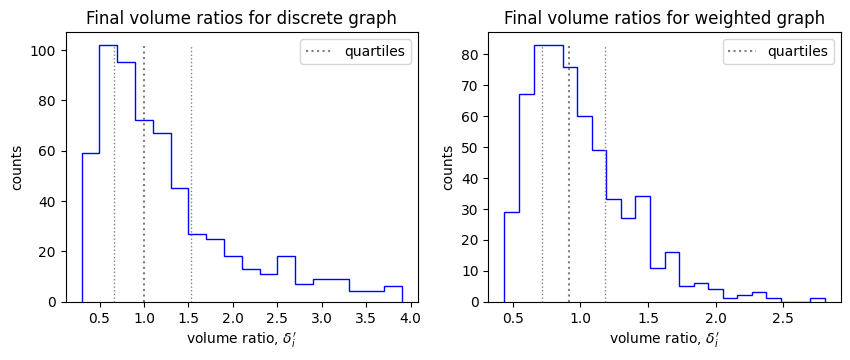

  N_seeds= 50  N_nbrs=  5  kNN=1.000  RDM=0.787  CKA=0.870  DB=nan
### Iteration 1 done. (0.39 s) - pruned 2 edge(s)
### Iteration 2 done. (0.05 s) - pruned 2 edge(s)
### Iteration 3 done. (0.05 s) - pruned 2 edge(s)
### Iteration 4 done. (0.05 s) - pruned 2 edge(s)
### Iteration 1 done. (0.39 s) - pruned 2 edge(s)
### Iteration 2 done. (0.05 s) - pruned 2 edge(s)
### Iteration 3 done. (0.05 s) - pruned 2 edge(s)
### Iteration 4 done. (0.05 s) - pruned 2 edge(s)
### Iteration 5 done. (0.05 s) - pruned 2 edge(s)
### Iteration 6 done. (0.05 s) - pruned 2 edge(s)
### Iteration 7 done. (0.05 s) - pruned 2 edge(s)
### Iteration 8 done. (0.05 s) - pruned 2 edge(s)
### Iteration 5 done. (0.05 s) - pruned 2 edge(s)
### Iteration 6 done. (0.05 s) - pruned 2 edge(s)
### Iteration 7 done. (0.05 s) - pruned 2 edge(s)
### Iteration 8 done. (0.05 s) - pruned 2 edge(s)
### Iteration 9 done. (0.05 s) - pruned 2 edge(s)
### Iteration 10 done. (0.05 s) - pruned 1 edge(s)
### Iteration 11 done. (0.05 s) 

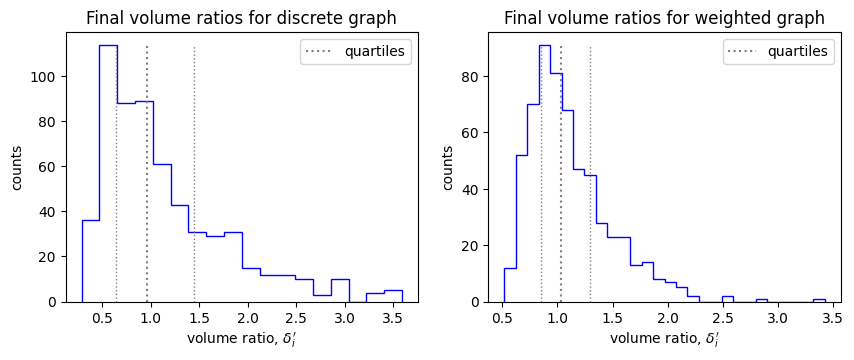

  N_seeds= 50  N_nbrs=  8  kNN=1.000  RDM=0.676  CKA=0.752  DB=nan
### Iteration 1 done. (0.32 s) - pruned 3 edge(s)
### Iteration 2 done. (0.06 s) - pruned 3 edge(s)
### Iteration 3 done. (0.05 s) - pruned 3 edge(s)
### Iteration 4 done. (0.06 s) - pruned 3 edge(s)
### Iteration 1 done. (0.32 s) - pruned 3 edge(s)
### Iteration 2 done. (0.06 s) - pruned 3 edge(s)
### Iteration 3 done. (0.05 s) - pruned 3 edge(s)
### Iteration 4 done. (0.06 s) - pruned 3 edge(s)
### Iteration 5 done. (0.05 s) - pruned 3 edge(s)
### Iteration 6 done. (0.05 s) - pruned 2 edge(s)
### Iteration 7 done. (0.05 s) - pruned 2 edge(s)
### Iteration 8 done. (0.05 s) - pruned 2 edge(s)
### Iteration 9 done. (0.05 s) - pruned 2 edge(s)
### Iteration 5 done. (0.05 s) - pruned 3 edge(s)
### Iteration 6 done. (0.05 s) - pruned 2 edge(s)
### Iteration 7 done. (0.05 s) - pruned 2 edge(s)
### Iteration 8 done. (0.05 s) - pruned 2 edge(s)
### Iteration 9 done. (0.05 s) - pruned 2 edge(s)
### Iteration 10 done. (0.05 s) -

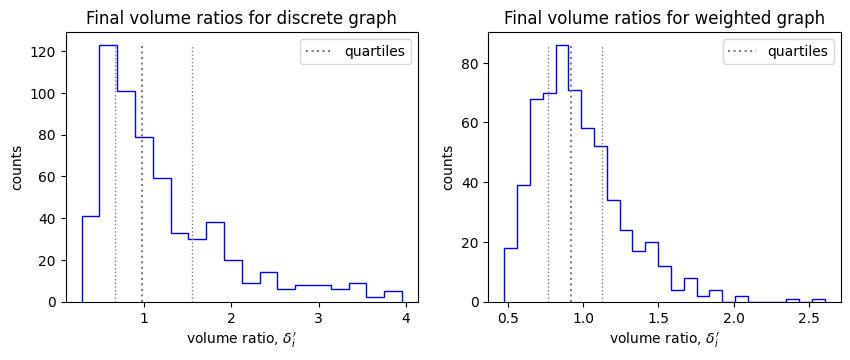

  N_seeds= 50  N_nbrs= 15  kNN=1.000  RDM=0.794  CKA=0.860  DB=0.25


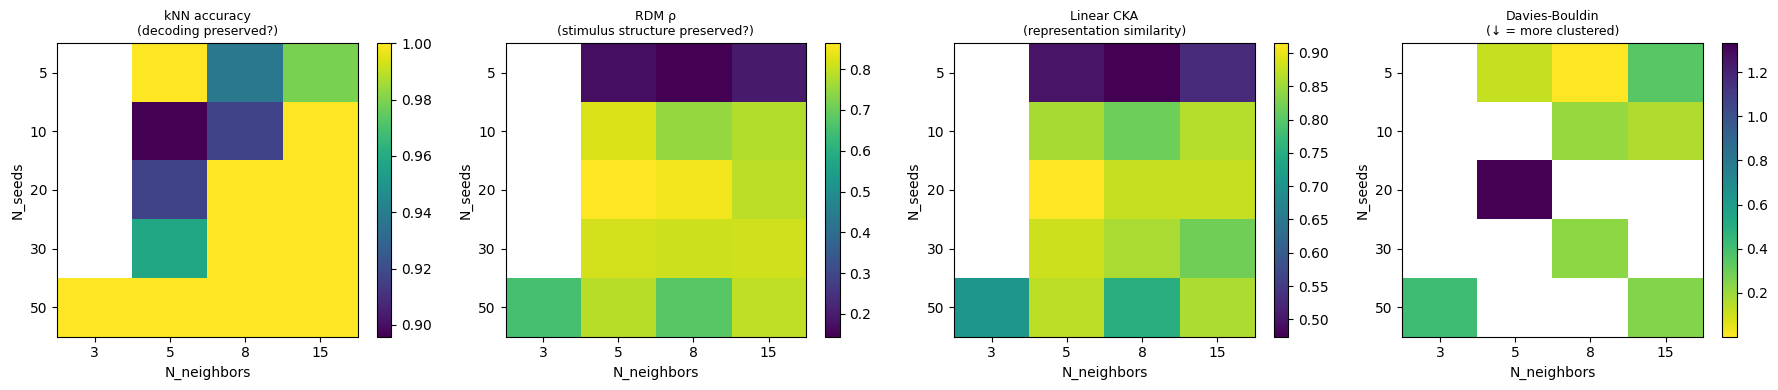


Most clustered: N_seeds=5, N_neighbors=8  DB=0.001  kNN=0.938  RDM=0.145  CKA=0.474
### Iteration 1 done. (0.31 s) - pruned 5 edge(s)
### Iteration 2 done. (0.06 s) - pruned 5 edge(s)
### Iteration 3 done. (0.06 s) - pruned 5 edge(s)
### Iteration 4 done. (0.05 s) - pruned 5 edge(s)
### Iteration 1 done. (0.31 s) - pruned 5 edge(s)
### Iteration 2 done. (0.06 s) - pruned 5 edge(s)
### Iteration 3 done. (0.06 s) - pruned 5 edge(s)
### Iteration 4 done. (0.05 s) - pruned 5 edge(s)
### Iteration 5 done. (0.05 s) - pruned 5 edge(s)
### Iteration 6 done. (0.05 s) - pruned 4 edge(s)
### Iteration 7 done. (0.06 s) - pruned 4 edge(s)
### Iteration 8 done. (0.05 s) - pruned 4 edge(s)
### Iteration 5 done. (0.05 s) - pruned 5 edge(s)
### Iteration 6 done. (0.05 s) - pruned 4 edge(s)
### Iteration 7 done. (0.06 s) - pruned 4 edge(s)
### Iteration 8 done. (0.05 s) - pruned 4 edge(s)
### Iteration 9 done. (0.46 s) - pruned 5 edge(s)
### Iteration 10 done. (0.05 s) - pruned 4 edge(s)
### Iteration 

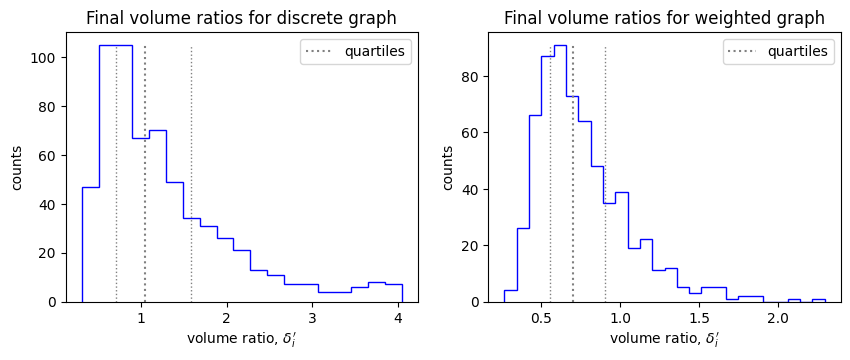

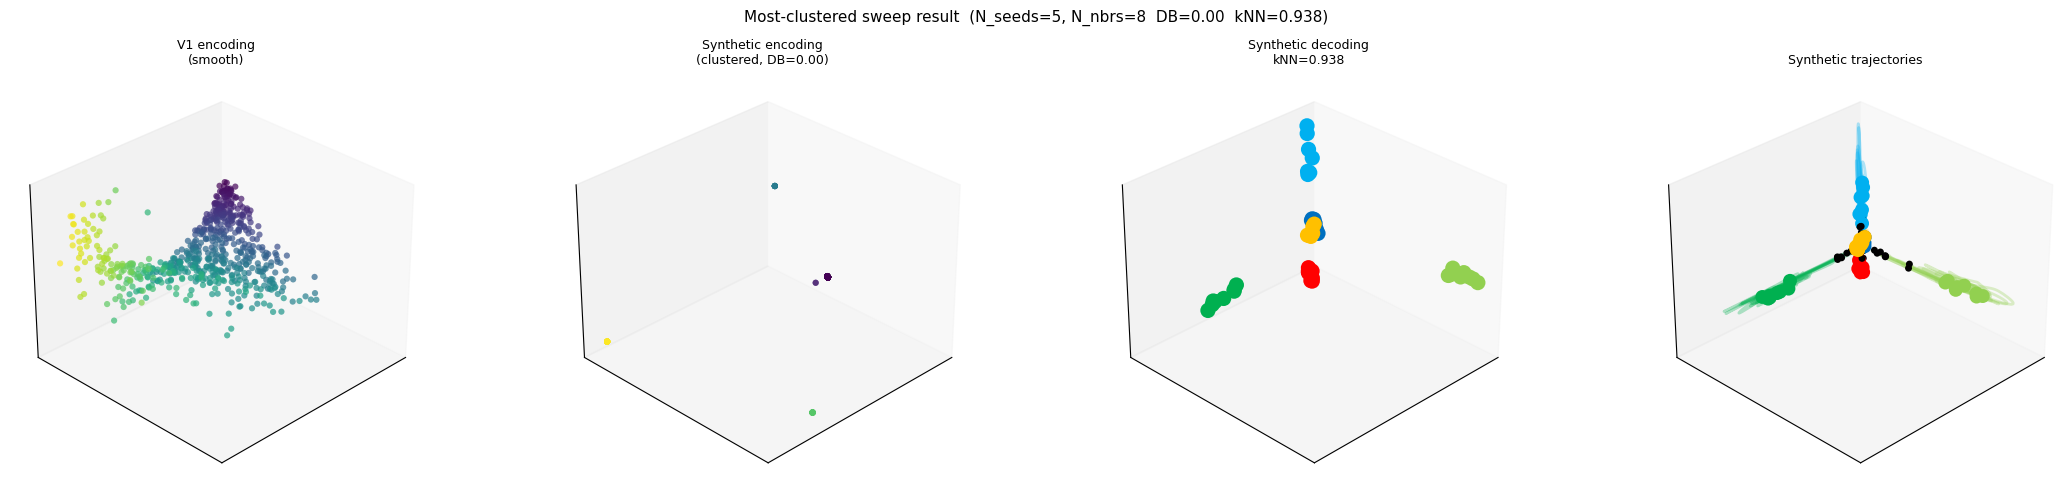

In [34]:
# ─── PARAMETERS ──────────────────────────────────────────────
SEEDS_RANGE     = [5, 10, 20, 30, 50]
NEIGHBORS_RANGE = [3, 5, 8, 15]
RUN_SWEEP       = True   # set to True to run (takes a few minutes)
# ───────────────────────────────────────────────

if RUN_SWEEP:
    from sklearn.metrics import davies_bouldin_score
    from src.manifold_utils import run_hdbscan_clustering

    shape = (len(SEEDS_RANGE), len(NEIGHBORS_RANGE))
    sweep_acc = np.full(shape, np.nan)
    sweep_db  = np.full(shape, np.nan)
    sweep_rdm = np.full(shape, np.nan)
    sweep_cka = np.full(shape, np.nan)

    # Store best synthetic tensor for post-sweep visualisation
    _best_tensor = None
    _best_enc    = None

    for si, ns in enumerate(SEEDS_RANGE):
        for ni, nn in enumerate(NEIGHBORS_RANGE):
            try:
                t_syn = create_synthetic_clustered_population(
                    tensor4d_NSDT, embedding_full, n_seeds=ns, n_neighbors=nn, rng_seed=42)

                # Decoding metrics
                coords_s, _ = compute_decoding_manifold(t_syn)
                acc_s = knn_decoding_accuracy(coords_s, stim_labels)
                rdm_s = rdm_correlation(tensor4d_NSDT, t_syn)
                cka_s = linear_cka(tensor4d_NSDT, t_syn)

                # Encoding: IAN manifold (may raise if identical points exist)
                enc_s = compute_encoding_manifold_from_tensor(t_syn)

                # Clusteredness via HDBSCAN
                labels_s, _, _, _ = run_hdbscan_clustering(
                    enc_s['diffmap_y'], enc_s['nPCs'], enc_s['wG'])
                valid = labels_s >= 0
                if valid.sum() > 1:
                    db = davies_bouldin_score(
                        enc_s['embedding_'][:, :3][valid], labels_s[valid])
                else:
                    db = np.nan

                sweep_acc[si, ni] = acc_s
                sweep_db[si, ni]  = db
                sweep_rdm[si, ni] = rdm_s
                sweep_cka[si, ni] = cka_s
                db_str = f'{db:.2f}' if not np.isnan(db) else 'nan'
                print(f'  N_seeds={ns:3d}  N_nbrs={nn:3d}  '
                      f'kNN={acc_s:.3f}  RDM={rdm_s:.3f}  CKA={cka_s:.3f}  DB={db_str}')

            except Exception as exc:
                print(f'  N_seeds={ns:3d}  N_nbrs={nn:3d}  '
                      f'SKIPPED ({type(exc).__name__}: {exc})')

    # ── Heatmaps: kNN, DB, RDM, CKA ────────────────────────────────────────
    fig, axes = plt.subplots(1, 4, figsize=(18, 4))
    hmap_specs = [
        (sweep_acc, 'kNN accuracy\n(decoding preserved?)', 'viridis', False),
        (sweep_rdm, 'RDM \u03c1\n(stimulus structure preserved?)', 'viridis', False),
        (sweep_cka, 'Linear CKA\n(representation similarity)', 'viridis', False),
        (sweep_db,  'Davies-Bouldin\n(\u2193 = more clustered)', 'viridis_r', True),
    ]
    for ax, (arr, title, cmap, _) in zip(axes, hmap_specs):
        im = ax.imshow(arr, aspect='auto', cmap=cmap)
        ax.set_xticks(range(len(NEIGHBORS_RANGE)))
        ax.set_xticklabels(NEIGHBORS_RANGE)
        ax.set_yticks(range(len(SEEDS_RANGE)))
        ax.set_yticklabels(SEEDS_RANGE)
        ax.set_xlabel('N_neighbors'); ax.set_ylabel('N_seeds')
        ax.set_title(title, fontsize=9)
        plt.colorbar(im, ax=ax)

    plt.tight_layout()
    plt.savefig(f'{BASEDIR_FIG}/{PREFIX}_param_sweep.pdf', bbox_inches='tight')
    plt.show()

    # ── Visualise most-clustered configuration ──────────────────────────────
    if not np.all(np.isnan(sweep_db)):
        best_si, best_ni = np.unravel_index(np.nanargmin(sweep_db), sweep_db.shape)
        best_ns = SEEDS_RANGE[best_si]
        best_nn = NEIGHBORS_RANGE[best_ni]
        print(f'\nMost clustered: N_seeds={best_ns}, N_neighbors={best_nn}  '
              f'DB={sweep_db[best_si, best_ni]:.3f}  '
              f'kNN={sweep_acc[best_si, best_ni]:.3f}  '
              f'RDM={sweep_rdm[best_si, best_ni]:.3f}  '
              f'CKA={sweep_cka[best_si, best_ni]:.3f}')

        t_best = create_synthetic_clustered_population(
            tensor4d_NSDT, embedding_full,
            n_seeds=best_ns, n_neighbors=best_nn, rng_seed=42)
        enc_best = compute_encoding_manifold_from_tensor(t_best)
        coords_best, _ = compute_decoding_manifold(t_best)
        trajs_best, _  = compute_decoding_trajectories(t_best)

        fig2 = plt.figure(figsize=(22, 5))
        fig2.suptitle(
            f'Most-clustered sweep result  (N_seeds={best_ns}, N_nbrs={best_nn}  '
            f'DB={sweep_db[best_si,best_ni]:.2f}  kNN={sweep_acc[best_si,best_ni]:.3f})',
            fontsize=11)

        # P1: real V1 encoding manifold
        ax_enc_v1 = fig2.add_subplot(1, 4, 1, projection='3d')
        dc0_v1 = embedding_full[:, 0]
        from matplotlib.colors import Normalize as _Norm
        import matplotlib.cm as _cm
        _norm = _Norm(vmin=dc0_v1.min(), vmax=dc0_v1.max())
        _cols = list(_cm.viridis(_norm(dc0_v1)))
        ax_enc_v1.scatter(*embedding_full[:, :3].T, c=_cols, s=20, alpha=0.7,
                          edgecolors='none', depthshade=False)
        ax_enc_v1.set_xticks([]); ax_enc_v1.set_yticks([]); ax_enc_v1.set_zticks([])
        ax_enc_v1.set_title('V1 encoding\n(smooth)', fontsize=9)
        ax_enc_v1.view_init(elev=30, azim=45)

        # P2: synthetic encoding manifold
        ax_enc_syn = fig2.add_subplot(1, 4, 2, projection='3d')
        emb_b = enc_best['embedding_']
        dc0_b = emb_b[:, 0]
        _norm_b = _Norm(vmin=dc0_b.min(), vmax=dc0_b.max())
        _cols_b = list(_cm.viridis(_norm_b(dc0_b)))
        ax_enc_syn.scatter(*emb_b[:, :3].T, c=_cols_b, s=20, alpha=0.7,
                           edgecolors='none', depthshade=False)
        ax_enc_syn.set_xticks([]); ax_enc_syn.set_yticks([]); ax_enc_syn.set_zticks([])
        ax_enc_syn.set_title(f'Synthetic encoding\n(clustered, DB={sweep_db[best_si,best_ni]:.2f})',
                             fontsize=9)
        ax_enc_syn.view_init(elev=30, azim=45)

        # P3: synthetic decoding manifold
        ax_dec = fig2.add_subplot(1, 4, 3, projection='3d')
        for si in range(NSTIMS):
            sel = stim_labels == si
            ax_dec.scatter(coords_best[sel, 0], coords_best[sel, 1], coords_best[sel, 2],
                           c=STIM_COLORS[si % len(STIM_COLORS)], s=120, alpha=1.0,
                           edgecolors='none', depthshade=False)
        ax_dec.set_xticks([]); ax_dec.set_yticks([]); ax_dec.set_zticks([])
        ax_dec.set_title(f'Synthetic decoding\nkNN={sweep_acc[best_si,best_ni]:.3f}', fontsize=9)
        ax_dec.view_init(elev=30, azim=45)

        # P4: synthetic decoding trajectories
        ax_tr = fig2.add_subplot(1, 4, 4, projection='3d')
        for i, traj in enumerate(trajs_best):
            si = i // NDIRS
            col = STIM_COLORS[si % len(STIM_COLORS)]
            valid = ~np.any(np.isnan(traj), axis=1)
            tv = traj[valid]
            if len(tv) < 2:
                continue
            ax_tr.plot(tv[:, 0], tv[:, 1], tv[:, 2],
                       color=col, linewidth=2, alpha=0.3)
            ax_tr.scatter(tv[0, 0], tv[0, 1], tv[0, 2],
                          color='black', s=25, edgecolors='none', depthshade=False)
            ax_tr.scatter(tv[-1, 0], tv[-1, 1], tv[-1, 2],
                          color=col, s=100, edgecolors='none', depthshade=False)
        ax_tr.set_xticks([]); ax_tr.set_yticks([]); ax_tr.set_zticks([])
        ax_tr.set_title('Synthetic trajectories', fontsize=9)
        ax_tr.view_init(elev=30, azim=45)

        plt.tight_layout()
        plt.savefig(f'{BASEDIR_FIG}/{PREFIX}_sweep_best.pdf', bbox_inches='tight')
        plt.show()
else:
    print('Set RUN_SWEEP = True to run parameter sweep.')


## 5 — Alternative Clustering Methods

Two alternative algorithms for constructing clustered synthetic populations:

- **Amplification** (`create_clustered_by_amplification`): blends each synthetic neuron's response toward a cluster seed via a random convex combination (α ∈ [0.6, 1.0] per stimulus).  Produces tighter intra-cluster tuning while keeping the full stimulus range.
- **Centroid + noise** (`create_clustered_by_centroid`): computes the mean response of each K-means cluster, then adds small Gaussian noise (5% of global std).  The tightest possible clusters — each cluster's neurons are near-identical copies of the centroid.

Both are compared to the shuffle-based baseline at `N_SEEDS=20` on all five decoding metrics.

Building populations...

Decoding metrics:
  [Shuffle]  kNN=1.000  RDM=0.847  CKA=0.876  R²=0.842  var=2.173
  [Amplify]  kNN=0.646  RDM=0.624  CKA=0.649  R²=0.511  var=0.503
  [Centroid]  kNN=0.562  RDM=0.808  CKA=0.766  R²=0.416  var=0.596

Building encoding manifolds...

Decoding metrics:
  [Shuffle]  kNN=1.000  RDM=0.847  CKA=0.876  R²=0.842  var=2.173
  [Amplify]  kNN=0.646  RDM=0.624  CKA=0.649  R²=0.511  var=0.503
  [Centroid]  kNN=0.562  RDM=0.808  CKA=0.766  R²=0.416  var=0.596

Building encoding manifolds...
### Iteration 1 done. (0.21 s) - pruned 3 edge(s)
### Iteration 2 done. (0.05 s) - pruned 3 edge(s)
### Iteration 3 done. (0.05 s) - pruned 3 edge(s)
### Iteration 4 done. (0.06 s) - pruned 2 edge(s)
### Iteration 1 done. (0.21 s) - pruned 3 edge(s)
### Iteration 2 done. (0.05 s) - pruned 3 edge(s)
### Iteration 3 done. (0.05 s) - pruned 3 edge(s)
### Iteration 4 done. (0.06 s) - pruned 2 edge(s)
### Iteration 5 done. (0.06 s) - pruned 2 edge(s)
### Iteration 6 done. (0.0

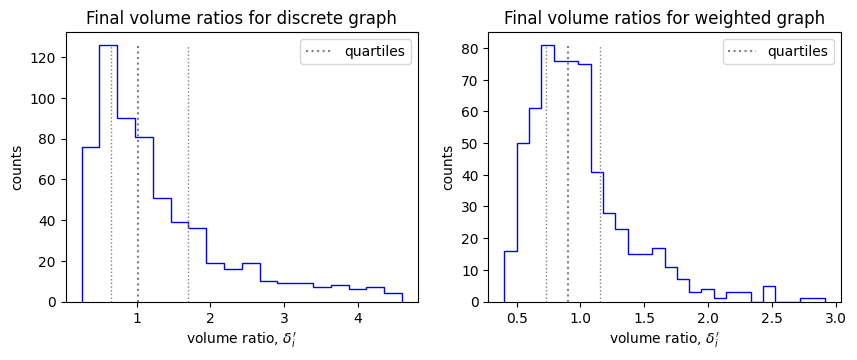

### Iteration 1 done. (0.07 s) - pruned 4 edge(s)
### Iteration 2 done. (0.03 s) - pruned 4 edge(s)
### Iteration 3 done. (0.03 s) - pruned 4 edge(s)
### Iteration 4 done. (0.03 s) - pruned 4 edge(s)
### Iteration 5 done. (0.04 s) - pruned 4 edge(s)
### Iteration 6 done. (0.04 s) - pruned 4 edge(s)
### Iteration 7 done. (0.04 s) - pruned 4 edge(s)
### Iteration 8 done. (0.03 s) - pruned 4 edge(s)
### Iteration 9 done. (0.04 s) - pruned 4 edge(s)
### Iteration 10 done. (0.03 s) - pruned 4 edge(s)
### Iteration 11 done. (0.04 s) - pruned 3 edge(s)
### Iteration 12 done. (0.05 s) - pruned 3 edge(s)
### Iteration 7 done. (0.04 s) - pruned 4 edge(s)
### Iteration 8 done. (0.03 s) - pruned 4 edge(s)
### Iteration 9 done. (0.04 s) - pruned 4 edge(s)
### Iteration 10 done. (0.03 s) - pruned 4 edge(s)
### Iteration 11 done. (0.04 s) - pruned 3 edge(s)
### Iteration 12 done. (0.05 s) - pruned 3 edge(s)
### Iteration 13 done. (0.14 s) - pruned 3 edge(s)
### Iteration 14 done. (0.07 s) - pruned 3 

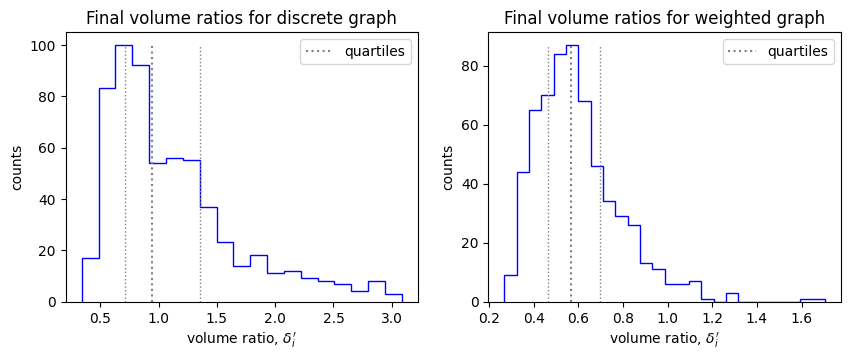

### Iteration 1 done. (0.06 s) - pruned 5 edge(s)
### Iteration 2 done. (0.03 s) - pruned 4 edge(s)
### Iteration 3 done. (0.03 s) - pruned 4 edge(s)
### Iteration 4 done. (0.03 s) - pruned 3 edge(s)
### Iteration 5 done. (0.03 s) - pruned 3 edge(s)
### Iteration 6 done. (0.03 s) - pruned 2 edge(s)
### Iteration 7 done. (0.03 s) - pruned 2 edge(s)
### Iteration 8 done. (0.03 s) - pruned 1 edge(s)
### Iteration 9 done. (0.05 s) - pruned 1 edge(s)
### Iteration 10 done. (0.04 s) - pruned 1 edge(s)
### Iteration 11 done. (0.04 s) - pruned 1 edge(s)
### Iteration 12 done. (0.04 s) - pruned 1 edge(s)
### Iteration 8 done. (0.03 s) - pruned 1 edge(s)
### Iteration 9 done. (0.05 s) - pruned 1 edge(s)
### Iteration 10 done. (0.04 s) - pruned 1 edge(s)
### Iteration 11 done. (0.04 s) - pruned 1 edge(s)
### Iteration 12 done. (0.04 s) - pruned 1 edge(s)
### Iteration 13 done. (0.04 s) - pruned 1 edge(s)
### Iteration 14 done. (0.03 s) - pruned 1 edge(s)
### Iteration 15 done. (0.03 s) - pruned 1

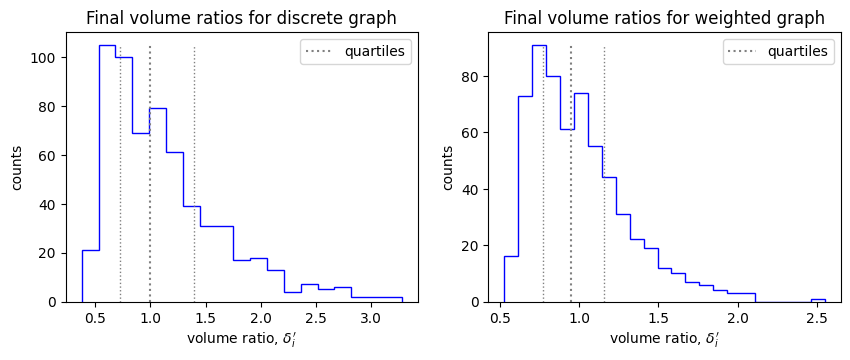

  DB scores — Shuffle: nan  Amplify: 0.000  Centroid: 0.000


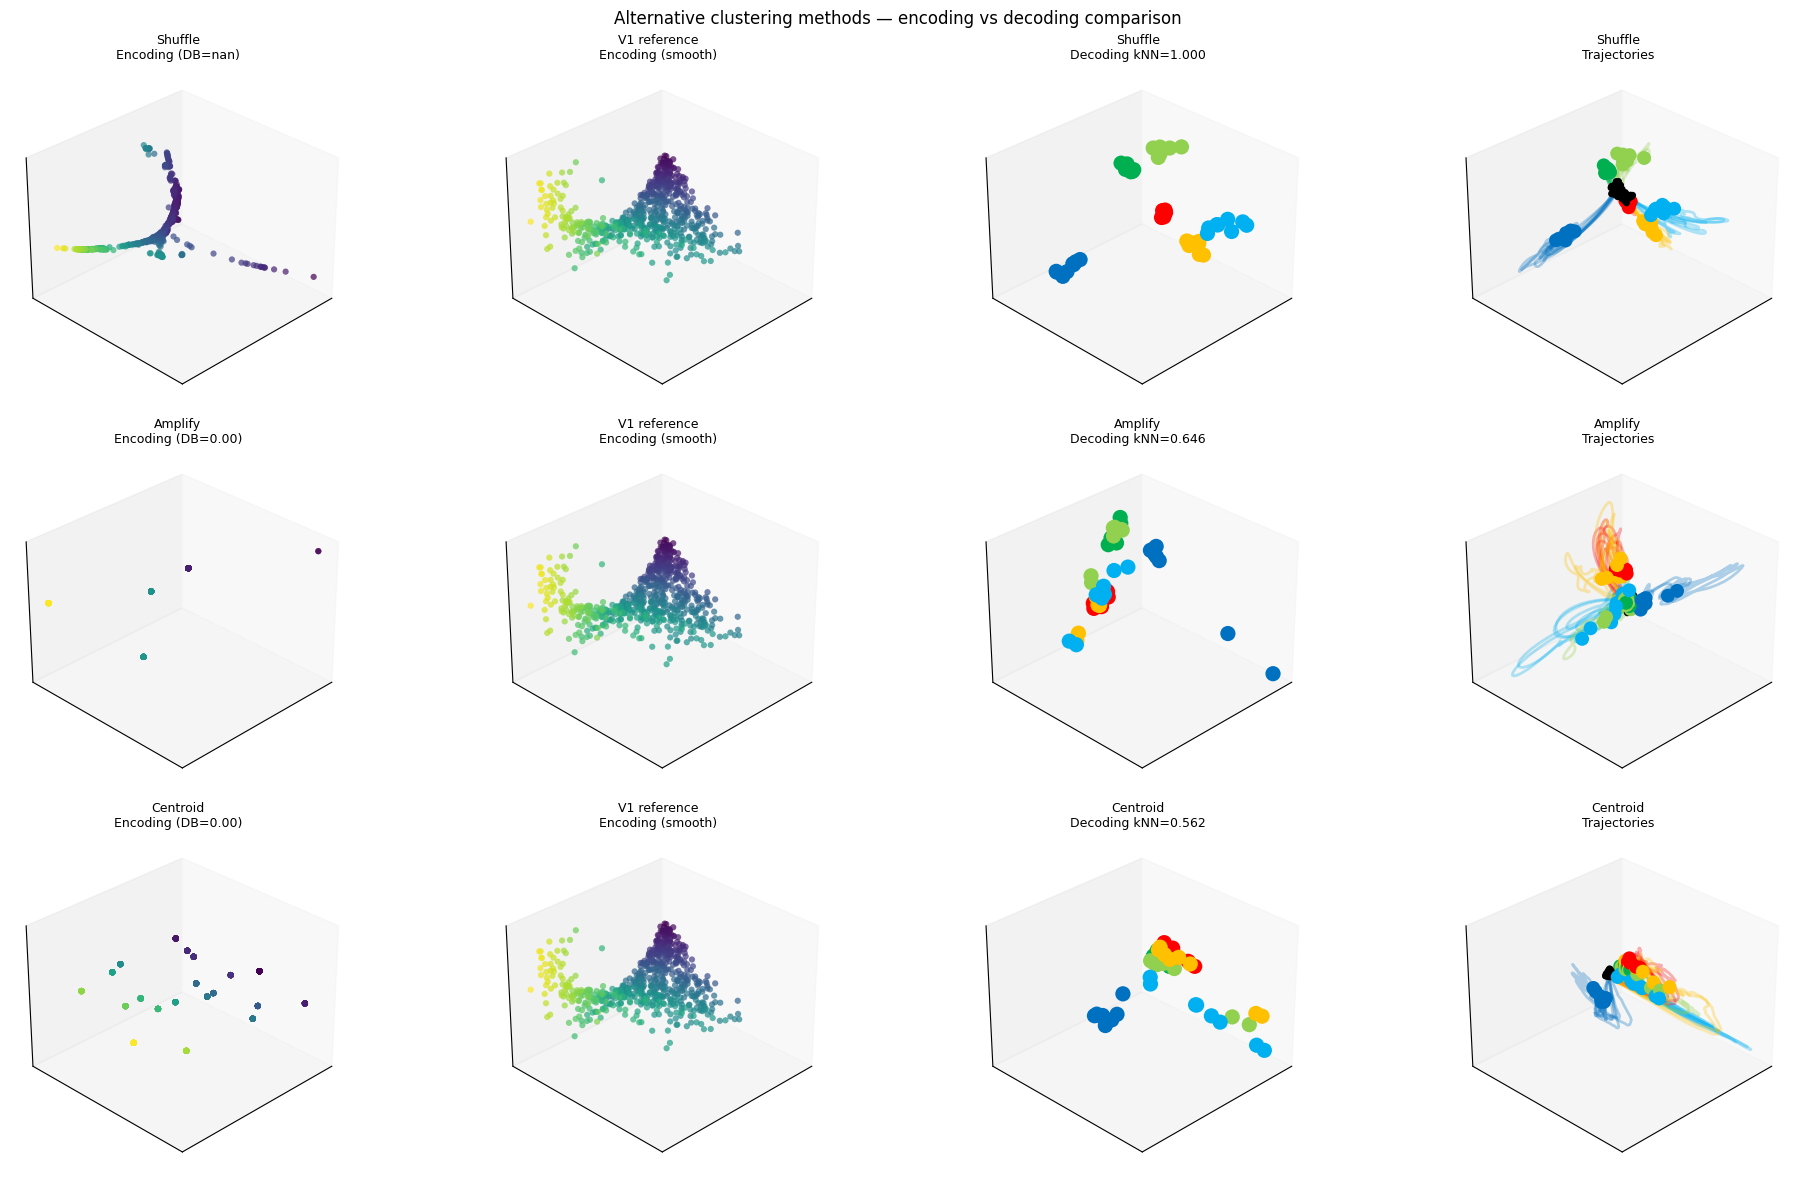

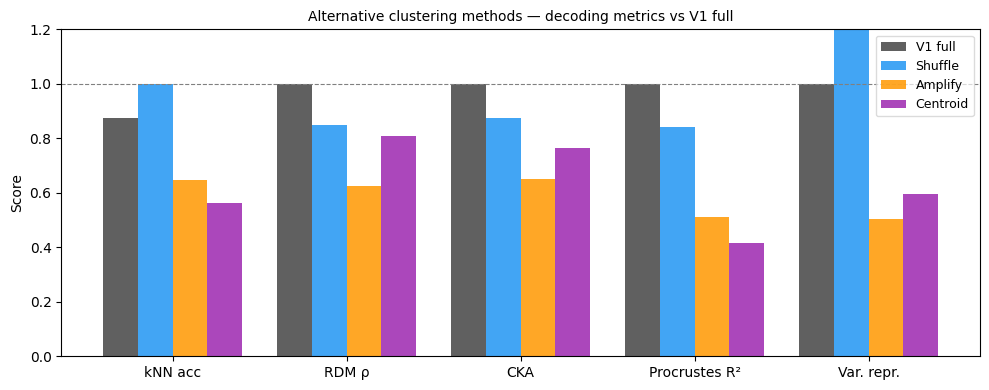

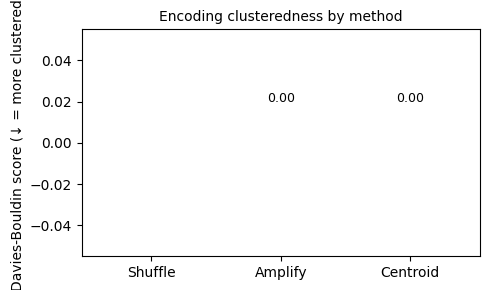

In [35]:
# ─── Alternative clustering comparison ───────────────────────────────────────
ALT_N_SEEDS     = 20
ALT_N_NEIGHBORS = 8
RUN_ALT = True   # set False to skip

if RUN_ALT:
    # ── 1. Build the three synthetic populations ─────────────────────────────
    print('Building populations...')
    t_shuffle = create_synthetic_clustered_population(
        tensor4d_NSDT, embedding_full,
        n_seeds=ALT_N_SEEDS, n_neighbors=ALT_N_NEIGHBORS, rng_seed=42)

    t_amplify = create_clustered_by_amplification(
        tensor4d_NSDT, embedding_full,
        n_seeds=ALT_N_SEEDS, n_neighbors=ALT_N_NEIGHBORS,
        alpha_range=(0.6, 1.0), rng_seed=42)

    t_centroid = create_clustered_by_centroid(
        tensor4d_NSDT, embedding_full,
        n_seeds=ALT_N_SEEDS, noise_scale=0.05, rng_seed=42)

    # ── 2. Decoding metrics for each ─────────────────────────────────────────
    def _decoding_metrics(tensor_syn, label):
        coords_s, _ = compute_decoding_manifold(tensor_syn)
        acc = knn_decoding_accuracy(coords_s, stim_labels)
        rdm = rdm_correlation(tensor4d_NSDT, tensor_syn)
        cka = linear_cka(tensor4d_NSDT, tensor_syn)
        r2  = procrustes_r2(coords_full, coords_s)
        var = variance_reproduced(coords_full, coords_s)
        print(f'  [{label}]  kNN={acc:.3f}  RDM={rdm:.3f}  '
              f'CKA={cka:.3f}  R\u00b2={r2:.3f}  var={var:.3f}')
        return dict(label=label, acc=acc, rdm=rdm, cka=cka, r2=r2, var=var,
                    coords=coords_s, tensor=tensor_syn)

    print('\nDecoding metrics:')
    res_full    = dict(label='V1 full',   acc=acc_full, rdm=1.0, cka=1.0,
                       r2=1.0, var=1.0, coords=coords_full, tensor=tensor4d_NSDT)
    res_shuffle = _decoding_metrics(t_shuffle,  'Shuffle')
    res_amplify = _decoding_metrics(t_amplify,  'Amplify')
    res_centroid= _decoding_metrics(t_centroid, 'Centroid')

    # ── 3. Encoding manifolds ─────────────────────────────────────────────────
    print('\nBuilding encoding manifolds...')
    enc_shuffle  = compute_encoding_manifold_from_tensor(t_shuffle)
    enc_amplify  = compute_encoding_manifold_from_tensor(t_amplify)
    enc_centroid = compute_encoding_manifold_from_tensor(t_centroid)

    from sklearn.metrics import davies_bouldin_score
    from src.manifold_utils import run_hdbscan_clustering
    from matplotlib.colors import Normalize as _Norm
    import matplotlib.cm as _cm

    def _db_score(enc):
        try:
            lbl, _, _, _ = run_hdbscan_clustering(
                enc['diffmap_y'], enc['nPCs'], enc['wG'])
            valid = lbl >= 0
            if valid.sum() > 1:
                return davies_bouldin_score(enc['embedding_'][:, :3][valid], lbl[valid])
        except Exception:
            pass
        return np.nan

    db_shuffle  = _db_score(enc_shuffle)
    db_amplify  = _db_score(enc_amplify)
    db_centroid = _db_score(enc_centroid)
    print(f'  DB scores — Shuffle: {db_shuffle:.3f}  '
          f'Amplify: {db_amplify:.3f}  Centroid: {db_centroid:.3f}')

    # ── 4. 3×4 comparison figure: encoding + decoding manifold + trajectories ─
    pop_specs = [
        ('Shuffle',  t_shuffle,  enc_shuffle,  res_shuffle),
        ('Amplify',  t_amplify,  enc_amplify,  res_amplify),
        ('Centroid', t_centroid, enc_centroid, res_centroid),
    ]

    fig = plt.figure(figsize=(20, 12))
    fig.suptitle('Alternative clustering methods — encoding vs decoding comparison',
                 fontsize=12)

    for row, (name, t_syn, enc_syn, res) in enumerate(pop_specs):
        trajs_syn, _ = compute_decoding_trajectories(t_syn)
        emb_s = enc_syn['embedding_']
        dc0_s = emb_s[:, 0]
        _norm_s = _Norm(vmin=dc0_s.min(), vmax=dc0_s.max())
        _cols_s = list(_cm.viridis(_norm_s(dc0_s)))

        # P1: encoding manifold
        ax_e = fig.add_subplot(3, 4, row * 4 + 1, projection='3d')
        ax_e.scatter(*emb_s[:, :3].T, c=_cols_s, s=20, alpha=0.7,
                     edgecolors='none', depthshade=False)
        ax_e.set_xticks([]); ax_e.set_yticks([]); ax_e.set_zticks([])
        db_str = f'{_db_score(enc_syn):.2f}' if not np.isnan(_db_score(enc_syn)) else 'nan'
        ax_e.set_title(f'{name}\nEncoding (DB={db_str})', fontsize=9)
        ax_e.view_init(elev=30, azim=45)

        # P2: V1 reference encoding (same for all rows)
        ax_v = fig.add_subplot(3, 4, row * 4 + 2, projection='3d')
        dc0_v = embedding_full[:, 0]
        _norm_v = _Norm(vmin=dc0_v.min(), vmax=dc0_v.max())
        _cols_v = list(_cm.viridis(_norm_v(dc0_v)))
        ax_v.scatter(*embedding_full[:, :3].T, c=_cols_v, s=20, alpha=0.7,
                     edgecolors='none', depthshade=False)
        ax_v.set_xticks([]); ax_v.set_yticks([]); ax_v.set_zticks([])
        ax_v.set_title('V1 reference\nEncoding (smooth)', fontsize=9)
        ax_v.view_init(elev=30, azim=45)

        # P3: decoding manifold
        ax_d = fig.add_subplot(3, 4, row * 4 + 3, projection='3d')
        coords_s = res['coords']
        for si in range(NSTIMS):
            sel = stim_labels == si
            ax_d.scatter(coords_s[sel, 0], coords_s[sel, 1], coords_s[sel, 2],
                         c=STIM_COLORS[si % len(STIM_COLORS)], s=120, alpha=1.0,
                         edgecolors='none', depthshade=False)
        ax_d.set_xticks([]); ax_d.set_yticks([]); ax_d.set_zticks([])
        ax_d.set_title(f'{name}\nDecoding kNN={res["acc"]:.3f}', fontsize=9)
        ax_d.view_init(elev=30, azim=45)

        # P4: decoding trajectories
        ax_t = fig.add_subplot(3, 4, row * 4 + 4, projection='3d')
        for i, traj in enumerate(trajs_syn):
            si = i // NDIRS
            col = STIM_COLORS[si % len(STIM_COLORS)]
            valid = ~np.any(np.isnan(traj), axis=1)
            tv = traj[valid]
            if len(tv) < 2:
                continue
            ax_t.plot(tv[:, 0], tv[:, 1], tv[:, 2],
                      color=col, linewidth=2, alpha=0.3)
            ax_t.scatter(tv[0, 0], tv[0, 1], tv[0, 2],
                         color='black', s=25, edgecolors='none', depthshade=False)
            ax_t.scatter(tv[-1, 0], tv[-1, 1], tv[-1, 2],
                         color=col, s=100, edgecolors='none', depthshade=False)
        ax_t.set_xticks([]); ax_t.set_yticks([]); ax_t.set_zticks([])
        ax_t.set_title(f'{name}\nTrajectories', fontsize=9)
        ax_t.view_init(elev=30, azim=45)

    plt.tight_layout()
    plt.savefig(f'{BASEDIR_FIG}/{PREFIX}_alt_clustering.pdf', bbox_inches='tight')
    plt.show()

    # ── 5. Bar chart comparison ───────────────────────────────────────────────
    conditions = [
        ('V1 full',   res_full),
        ('Shuffle',   res_shuffle),
        ('Amplify',   res_amplify),
        ('Centroid',  res_centroid),
    ]
    metric_keys = ['acc', 'rdm', 'cka', 'r2', 'var']
    metric_labels = ['kNN acc', 'RDM \u03c1', 'CKA', 'Procrustes R\u00b2', 'Var. repr.']
    n_cond   = len(conditions)
    n_metric = len(metric_keys)
    x = np.arange(n_metric)
    width = 0.8 / n_cond
    bar_colors = ['#444444', '#2196F3', '#FF9800', '#9C27B0']

    fig_bar, ax_bar = plt.subplots(figsize=(10, 4))
    for ci, (cname, res) in enumerate(conditions):
        vals = [res[k] if res[k] is not None and not np.isnan(res[k]) else 0
                for k in metric_keys]
        ax_bar.bar(x + ci * width - 0.4 + width / 2, vals, width,
                   label=cname, color=bar_colors[ci % len(bar_colors)], alpha=0.85)
    ax_bar.set_xticks(x); ax_bar.set_xticklabels(metric_labels)
    ax_bar.set_ylabel('Score'); ax_bar.set_ylim(0, 1.2)
    ax_bar.axhline(1.0, color='gray', lw=0.8, ls='--')
    ax_bar.legend(fontsize=9, framealpha=0.7)
    ax_bar.set_title('Alternative clustering methods — decoding metrics vs V1 full', fontsize=10)
    plt.tight_layout()
    plt.savefig(f'{BASEDIR_FIG}/{PREFIX}_alt_bar.pdf', bbox_inches='tight')
    plt.show()

    # ── 6. DB score comparison bar ────────────────────────────────────────────
    db_labels = ['Shuffle', 'Amplify', 'Centroid']
    db_vals   = [db_shuffle, db_amplify, db_centroid]
    fig_db, ax_db = plt.subplots(figsize=(5, 3))
    bars = ax_db.bar(db_labels,
                     [v if not np.isnan(v) else 0 for v in db_vals],
                     color=['#2196F3', '#FF9800', '#9C27B0'], alpha=0.85)
    ax_db.set_ylabel('Davies-Bouldin score (\u2193 = more clustered)')
    ax_db.set_title('Encoding clusteredness by method', fontsize=10)
    for bar, val in zip(bars, db_vals):
        if not np.isnan(val):
            ax_db.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02,
                       f'{val:.2f}', ha='center', fontsize=9)
    plt.tight_layout()
    plt.savefig(f'{BASEDIR_FIG}/{PREFIX}_alt_db.pdf', bbox_inches='tight')
    plt.show()

else:
    print('Set RUN_ALT = True to run alternative clustering analysis.')
